In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import re
import csv
import codecs
import urllib.request
import urllib.error
import sys
from dotenv import load_dotenv

### 1 file

In [13]:
sunflower_df = pd.read_csv("./data_1/field_62/2022_sunflower.csv")

In [3]:
sunflower_df.head()

,DISTANCE,SWATHWIDTH,VRYIELDMAS,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,...,Fe,Zn,S,P,P_Index,K,K_Index,Na,pH,C.E.C
0,2.94795,9.300004,1.305388,-1201171,22,1.305388,7.7,10/9/2022 5:38:03 PM,27.358735,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
1,2.88906,9.300004,1.276285,-1201171,22,1.276285,7.8,10/9/2022 5:38:04 PM,26.132605,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
2,2.86502,9.300004,1.346578,-1201171,22,1.346578,7.7,10/9/2022 5:38:05 PM,24.992419,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
3,2.38688,9.300004,1.632671,-1201171,22,1.632671,7.7,10/9/2022 5:38:06 PM,24.556971,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
4,2.24921,9.300004,1.431187,-1201171,22,1.431187,7.7,10/9/2022 5:38:07 PM,25.479433,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5


<Axes: title={'center': 'Plot of Column VRYIELDMAS'}, xlabel='number of values in dataset', ylabel='yield value'>

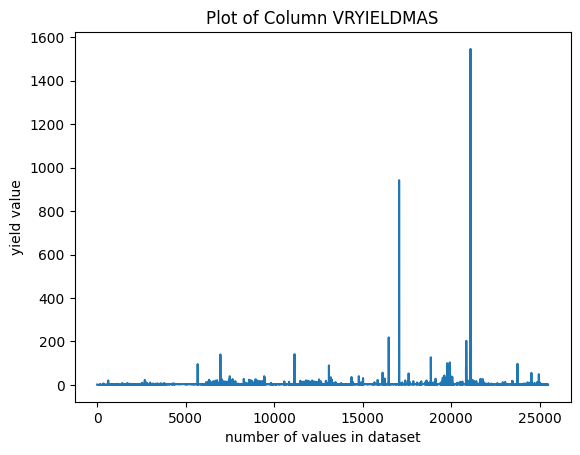

In [15]:
column = 'VRYIELDMAS'
sunflower_df[column].plot(kind='line', title=f'Plot of Column {column}', xlabel="number of values in dataset", ylabel="yield value")

In [5]:
print(sunflower_df[column].describe())

count    25455.000000
mean         2.964375
std         11.889113
min          0.003155
25%          1.962196
50%          2.933153
75%          3.441555
max       1546.409630
Name: VRYIELDMAS, dtype: float64


Text(0.5, 0, 'Yield value')

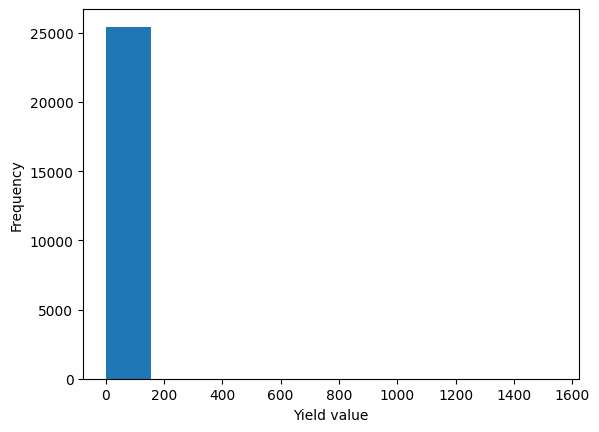

In [6]:
sunflower_df[column].plot.hist()
plt.xlabel("Yield value")

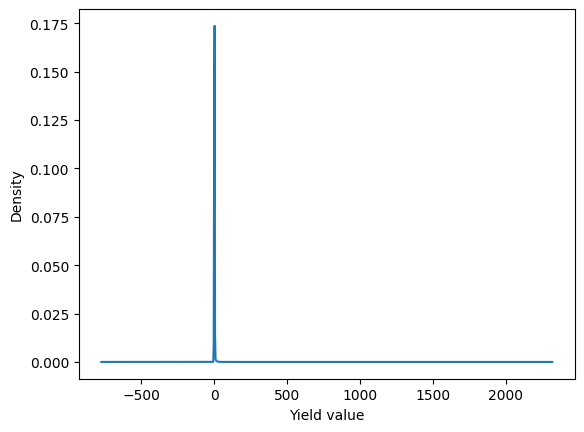

In [7]:
sunflower_df[column].plot.density()
plt.xlabel("Yield value")
plt.show()

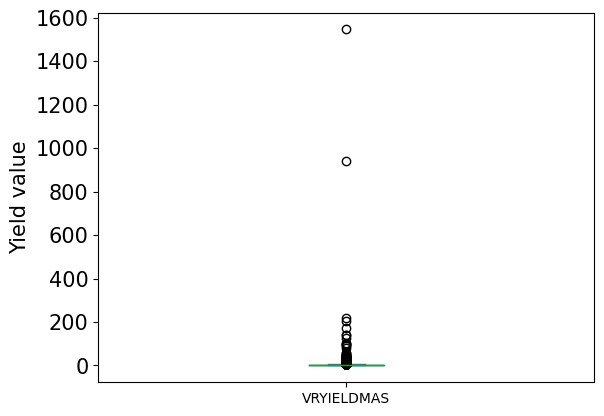

In [21]:
sunflower_df[column].plot.box()
plt.ylabel("Yield value", fontsize=15)
plt.yticks(fontsize=15)
plt.show()

Lower bound: -0.25684158999999984
Upper bound: 5.6605928500000005


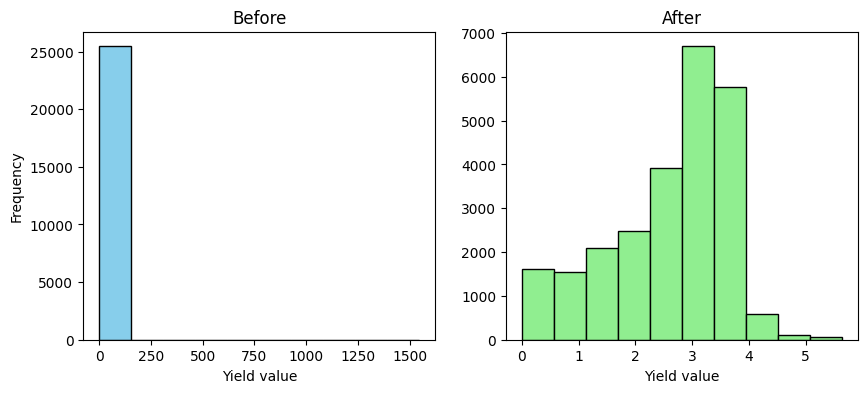

In [9]:
col = sunflower_df[column].astype(float) 
Q1 = np.percentile(col, 25)
Q3 = np.percentile(col, 75)
IQR = Q3 - Q1
MEAN = sunflower_df[column].mean()

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

sunflower_df_ = sunflower_df[
    (sunflower_df[column] >= lower_bound) &
    (sunflower_df[column] <= upper_bound)
]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(sunflower_df[column], bins=10, color="skyblue", edgecolor="black")
plt.title("Before")
plt.xlabel("Yield value")
plt.ylabel("Frequency")
plt.subplot(1,2,2)
plt.hist(sunflower_df_[column], bins=10, color="lightgreen", edgecolor="black")
plt.title("After")
plt.xlabel("Yield value")
# plt.ylabel("the number of data points with these values")
plt.show()

In [10]:
print(sunflower_df_[column].describe())

count    24897.000000
mean         2.600782
std          1.066422
min          0.003155
25%          1.928172
50%          2.905378
75%          3.408583
max          5.641562
Name: VRYIELDMAS, dtype: float64


In [11]:
len(sunflower_df_)

24897

[]

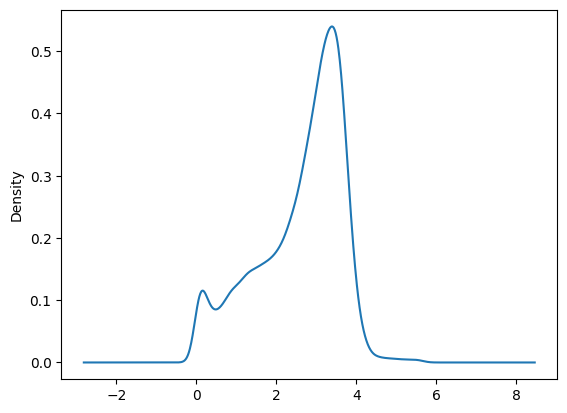

In [12]:
sunflower_df_[column].plot.density()
plt.plot()

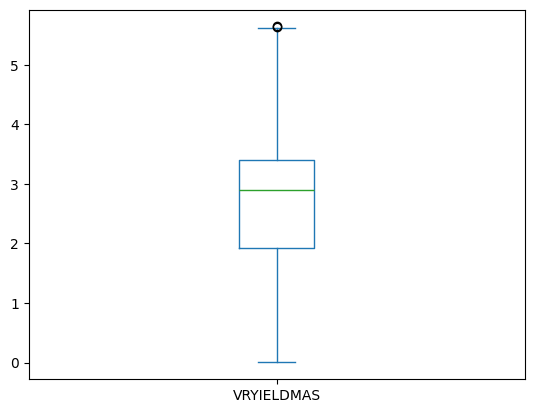

In [13]:
sunflower_df_[column].plot.box()
plt.show()

In [15]:
sunflower_df_.columns

Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'FUEL', 'VEHICLSPEED', 'DRYMATTER', 'PRODUCTHASH', 'xcoord',
       'ycoord', 'area', 'CROPNAME_', 'FIELDREF', 'Organic M', 'Ca', 'Mg',
       'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P', 'P_Index', 'K',
       'K_Index', 'Na', 'pH', 'C.E.C'],
      dtype='object')

In [16]:
clear_sunflower_df = sunflower_df_.drop(columns=['FIELDREF', 'DISTANCE', 'SWATHWIDTH', 'WetMass', 'Time', 'Heading', 'VARIETY', 'IsoTime', 'Machine', 'FUEL', 'VEHICLSPEED', 'PRODUCTHASH'])
clear_sunflower_df.head()

,VRYIELDMAS,SECTIONID,Crop,Moisture,Elevation,DRYMATTER,xcoord,ycoord,area,CROPNAME_,...,Fe,Zn,S,P,P_Index,K,K_Index,Na,pH,C.E.C
0,1.305388,-1201171,22,7.7,83.607,92.3,25.837112,48.828905,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
1,1.276285,-1201171,22,7.8,83.485,92.2,25.837130,48.828928,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
2,1.346578,-1201171,22,7.7,83.332,92.3,25.837147,48.828951,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
3,1.632671,-1201171,22,7.7,83.210,92.3,25.837160,48.828970,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
4,1.431187,-1201171,22,7.7,83.119,92.3,25.837173,48.828989,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5


In [ ]:
clear_sunflower_df = clear_sunflower_df.dropna()

In [18]:
# clear_sunflower_df.head

In [19]:
clear_sunflower_df.to_csv('./data_1/2022_sunflower_.csv', index=False)

### Погода

In [20]:
BaseURL = 'https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/'

In [21]:
load_dotenv() 
API_KEY = os.getenv("API_KEY")
# print(API_KEY)

In [22]:
UnitGroup='metric'
Location='Ternopil,UK'
StartDate = '2017-05-01'
EndDate='2017-10-31'
ContentType="csv"
Include="days"

In [ ]:
ApiQuery = BaseURL + Location

if (len(StartDate)):
    ApiQuery += "/" + StartDate
    if (len(EndDate)):
        ApiQuery += "/" + EndDate

ApiQuery += "?"

if (len(UnitGroup)):
    ApiQuery += "&unitGroup=" + UnitGroup

if (len(ContentType)):
    ApiQuery += "&contentType=" + ContentType

if (len(Include)):
    ApiQuery += "&include=" + Include

ApiQuery += "&key=" + API_KEY

print(' - Running query URL: ', ApiQuery)
print()

try:
    CSVBytes = urllib.request.urlopen(ApiQuery)
except urllib.error.HTTPError as e:
    ErrorInfo = e.read().decode()
    print('Error code: ', e.code, ErrorInfo)
    sys.exit()
except urllib.error.URLError as e:
    ErrorInfo = e.read().decode()
    print("Error code: ", e.code, ErrorInfo)
    sys.exit()

In [ ]:
CSVText = csv.reader(codecs.iterdecode(CSVBytes, 'utf-8'))

with open("./data_1/weather_data/weather_data_2017.csv", "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    for row in CSVText:
        writer.writerow(row)

In [3]:
weather_df = pd.DataFrame()

folder_path = './data_1/weather_data'
regex = r"^weather_data_\d{4}\.csv$"

all_data_frames = []
file_list = os.listdir(folder_path)

for i in file_list:
    if re.search(regex, i):
        year = (i.split('_')[2])
        year_ = int(year.split('.')[0])
        new_df = pd.read_csv(os.path.join(folder_path, i))
        new_df['year'] = year_
        all_data_frames.append(new_df)
        weather_df = pd.concat([weather_df, new_df], ignore_index=True)

weather_df.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations,year
0,"Тернопіль, Україна",2017-05-01,10.6,3.5,6.8,10.6,1.9,5.6,3.4,79.6,...,7.0,NaN,2017-05-01T05:55:15,2017-05-01T20:35:10,0.17,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"33415099999,remote",2017
1,"Тернопіль, Україна",2017-05-02,16.8,5.2,10.3,16.8,2.5,9.2,6.1,76.1,...,7.0,NaN,2017-05-02T05:53:31,2017-05-02T20:36:40,0.20,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"33415099999,remote",2017
2,"Тернопіль, Україна",2017-05-03,21.8,6.4,14.1,21.8,4.1,13.4,8.6,71.8,...,8.0,NaN,2017-05-03T05:51:49,2017-05-03T20:38:10,0.25,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"33415099999,remote",2017
3,"Тернопіль, Україна",2017-05-04,24.2,10.9,17.1,24.2,10.9,17.1,9.8,65.1,...,8.0,NaN,2017-05-04T05:50:08,2017-05-04T20:39:39,0.27,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,"33415099999,remote",2017
4,"Тернопіль, Україна",2017-05-05,22.2,11.7,16.5,22.2,11.7,16.5,10.2,69.3,...,7.0,NaN,2017-05-05T05:48:28,2017-05-05T20:41:08,0.31,"Rain, Partially cloudy",Partly cloudy throughout the day with morning ...,rain,"33415099999,remote",2017


In [ ]:
weather_df.columns

Index(['name', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations',
       'year'],
      dtype='object')

In [ ]:
weather_df.isna().sum()

name                   0
datetime               0
tempmax                0
tempmin                0
temp                   0
feelslikemax           0
feelslikemin           0
feelslike              0
dew                    0
humidity               0
precip                 0
precipprob             0
precipcover            0
preciptype           508
snow                   0
snowdepth              0
windgust               0
windspeed              0
winddir                0
sealevelpressure       0
cloudcover             0
visibility             3
solarradiation         1
solarenergy            1
uvindex                1
severerisk          1266
sunrise                0
sunset                 0
moonphase              0
conditions             0
description            0
icon                   0
stations               0
year                   0
dtype: int64

In [ ]:
weather_df["tempmax"].isna().sum()

0

In [ ]:
weather_df["tempmin"].isna().sum()

0

In [ ]:
weather_df["temp"].isna().sum()

0

In [ ]:
weather_df["humidity"].isna().sum()

0

In [ ]:
weather_df["precip"].isna().sum()

0

In [ ]:
weather_df["cloudcover"].isna().sum()

0

In [4]:
plot_df = weather_df.copy()

In [5]:
plot_df['datetime'] = pd.to_datetime(plot_df['datetime'])
plot_df['year'] = plot_df['datetime'].dt.year
plot_df['month'] = plot_df['datetime'].dt.month
yearly = plot_df.groupby('year')[['tempmin', 'tempmax', 'temp', 'humidity', 'precip', 'cloudcover']].mean()

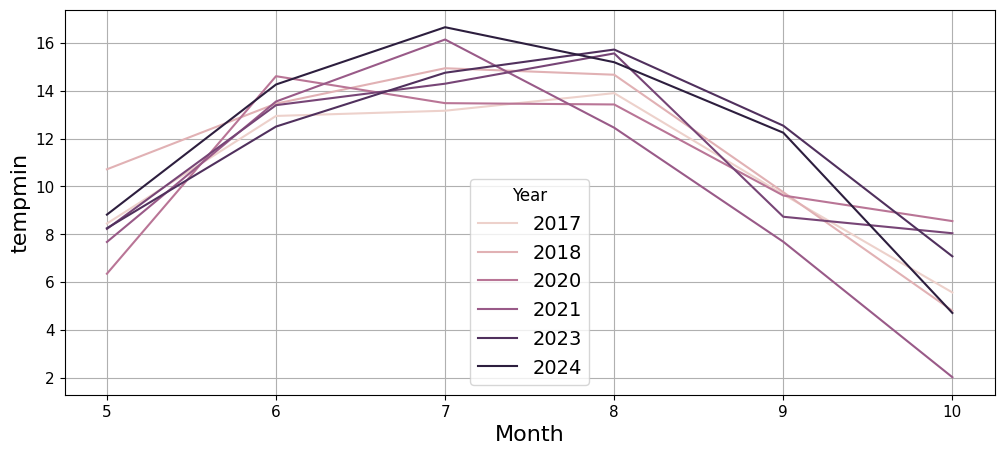

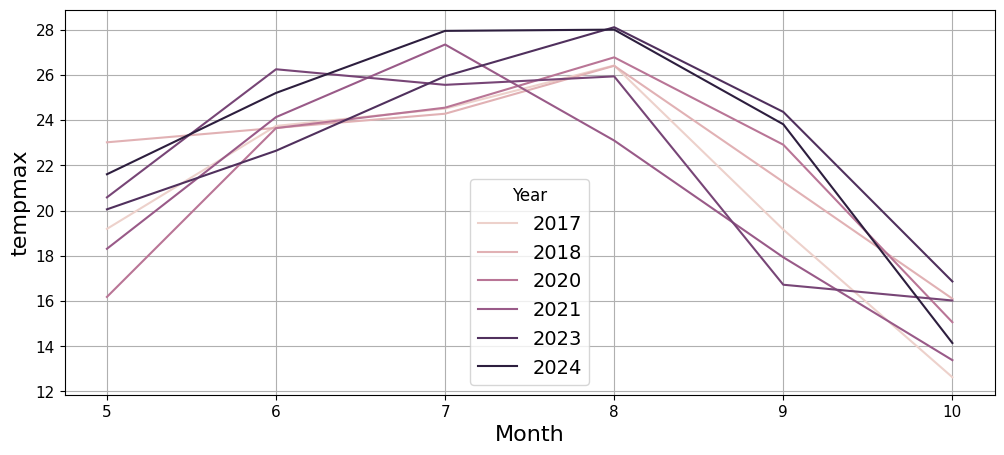

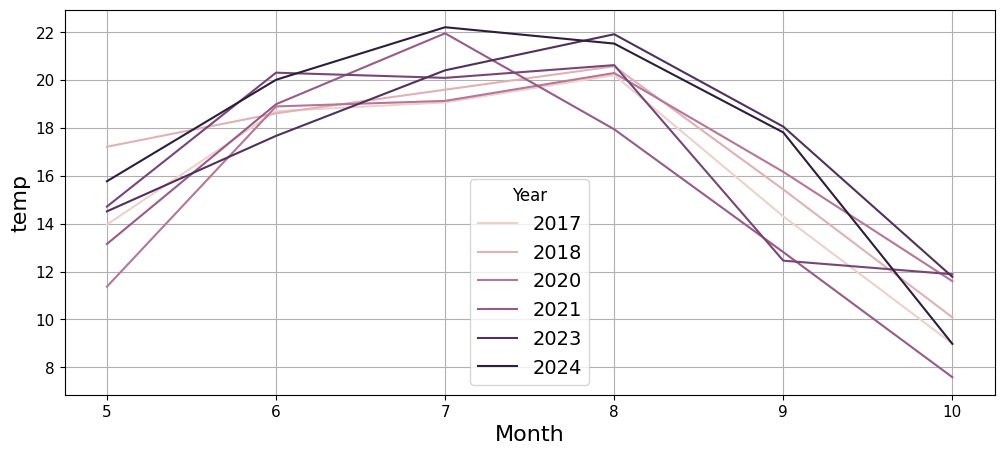

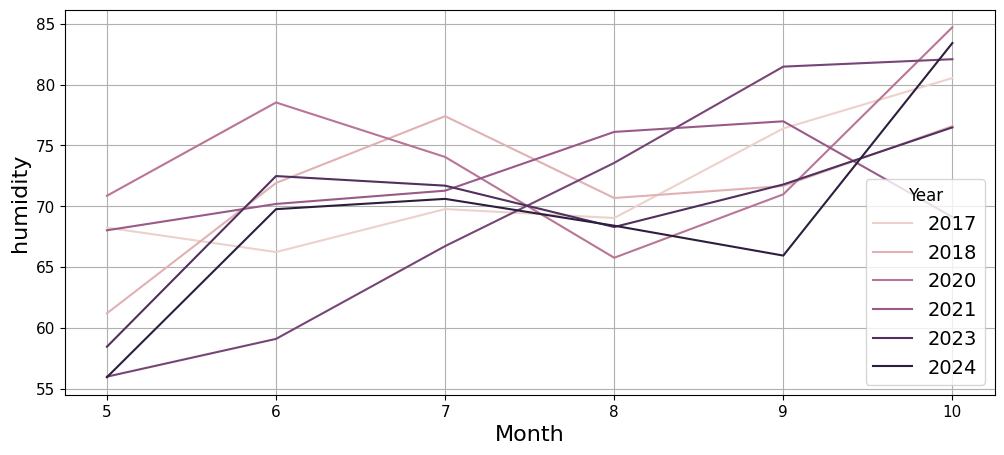

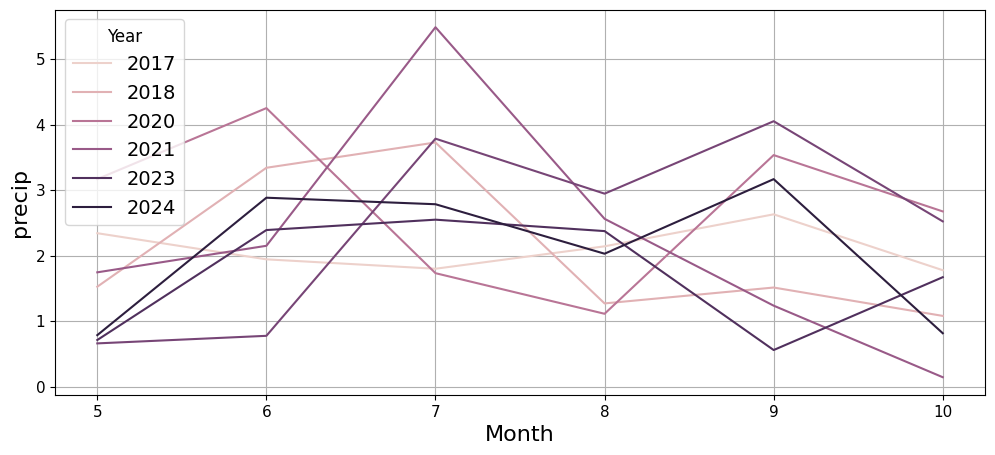

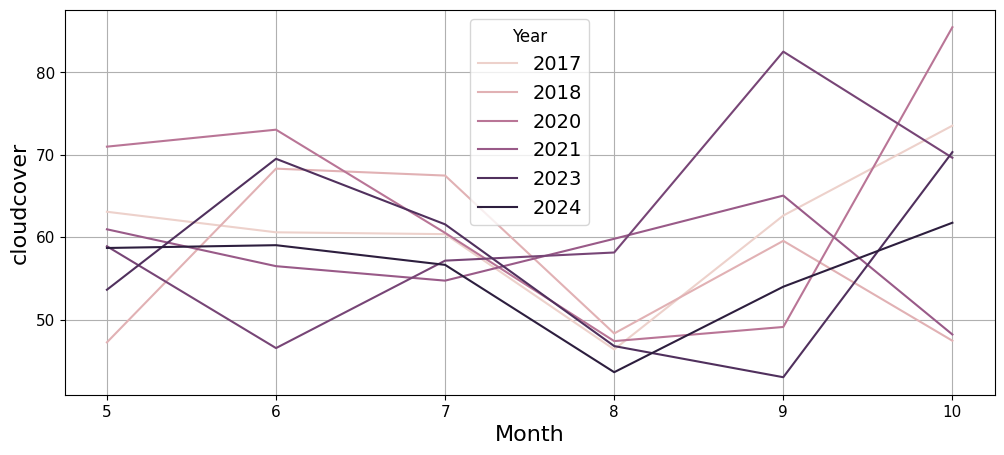

In [12]:
cols = ['tempmin', 'tempmax', 'temp', 'humidity', 'precip', 'cloudcover']

monthly = plot_df.groupby(['year', 'month'])[cols].mean().reset_index()

for col in cols:
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=monthly, x='month', y=col, hue='year')
    # plt.title(f"{col} monthly trend by year", fontsize=16)
    plt.xlabel('Month', fontsize=16)
    plt.ylabel(col, fontsize=16)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.legend(title='Year', title_fontsize=12, fontsize=14)
    plt.grid(True)
    plt.show()

In [ ]:
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
weather_df['month'] = weather_df['datetime'].dt.month

weather_df_ = weather_df.groupby(['year', 'month']).agg(
    max_tempmax = ("tempmax", "max"), 
    min_tempmax = ("tempmax", "min"), 
    mean_tempmax = ("tempmax", "mean"),
    std_tempmax = ("tempmax", "std"), 

    max_tempmin = ("tempmin", "max"), 
    min_tempmin = ("tempmin", "min"), 
    mean_tempmin = ("tempmin", "mean"), 
    std_tempmin = ("tempmin", "std"), 

    max_temp = ("temp", "max"), 
    min_temp = ("temp", "min"), 
    mean_temp = ("temp", "mean"),
    std_temp = ("temp", "std"), 
    
    max_humidity = ("humidity", "max"), 
    min_humidity = ("humidity", "min"), 
    mean_humidity = ("humidity", "mean"), 
    std_humidity = ("humidity", "std"), 

    max_precip = ("precip", "max"), 
    min_precip = ("precip", "min"), 
    mean_precip = ("precip", "mean"), 
    std_precip = ("precip", "std"), 

    max_cloudcover = ("cloudcover", "max"), 
    min_cloudcover = ("cloudcover", "min"), 
    mean_cloudcover = ("cloudcover", "mean"),
    std_cloudcover = ("cloudcover", "std"), 
).reset_index()

In [ ]:
weather_df_

,year,month,max_tempmax,min_tempmax,mean_tempmax,std_tempmax,max_tempmin,min_tempmin,mean_tempmin,std_tempmin,...,mean_humidity,std_humidity,max_precip,min_precip,mean_precip,std_precip,max_cloudcover,min_cloudcover,mean_cloudcover,std_cloudcover
0,2017,5,26.9,8.6,19.190323,4.896622,15.3,-0.6,8.451613,3.562197,...,68.241935,12.440305,19.0,0.0,2.341935,4.051401,98.0,18.3,63.080645,20.703984
1,2017,6,31.4,16.2,23.743333,3.421099,18.0,7.9,12.943333,2.922054,...,66.230000,9.014630,20.0,0.0,1.943333,4.396290,99.6,29.1,60.586667,20.713809
2,2017,7,32.0,19.6,24.509677,3.553623,18.0,8.5,13.161290,2.527011,...,69.767742,7.403710,14.0,0.0,1.800000,3.500857,93.6,3.4,60.364516,21.023757
3,2017,8,34.0,15.4,26.416129,5.678679,21.1,5.9,13.896774,3.694003,...,69.032258,10.159376,15.4,0.0,2.141935,4.222541,98.8,1.4,46.370968,29.033489
4,2017,9,27.6,12.6,19.160000,4.300168,15.9,1.4,9.666667,3.381117,...,76.403333,9.582221,21.0,0.0,2.630000,5.139244,100.0,0.5,62.620000,28.635274
5,2017,10,22.6,3.4,12.629032,5.030917,12.4,-0.8,5.570968,3.512567,...,80.548387,7.376579,11.0,0.0,1.777419,2.674660,100.0,7.4,73.532258,26.921446
6,2018,5,29.7,14.9,23.019355,4.256244,14.1,6.2,10.716129,2.139485,...,61.187097,12.818001,20.0,0.0,1.525806,3.726926,89.1,1.3,47.229032,24.902733
7,2018,6,29.9,12.6,23.656667,4.093197,17.8,7.6,13.456667,2.673843,...,71.913333,12.960038,23.0,0.0,3.340000,5.368465,99.0,12.0,68.313333,24.864623
8,2018,7,29.3,15.4,24.283871,3.147708,18.6,9.0,14.935484,2.592238,...,77.409677,8.851454,26.0,0.0,3.725806,6.168899,96.4,29.6,67.474194,18.293386
9,2018,8,29.8,18.1,26.403226,2.787051,18.4,10.2,14.664516,2.048503,...,70.677419,8.075961,8.0,0.0,1.270968,2.225188,99.5,5.2,48.309677,24.280985


In [ ]:
weather_df_.isna().sum()

year               0
month              0
max_tempmax        0
min_tempmax        0
mean_tempmax       0
std_tempmax        0
max_tempmin        0
min_tempmin        0
mean_tempmin       0
std_tempmin        0
max_temp           0
min_temp           0
mean_temp          0
std_temp           0
max_humidity       0
min_humidity       0
mean_humidity      0
std_humidity       0
max_precip         0
min_precip         0
mean_precip        0
std_precip         0
max_cloudcover     0
min_cloudcover     0
mean_cloudcover    0
std_cloudcover     0
dtype: int64

In [ ]:
wether_table = weather_df_.pivot(
    index="year", 
    columns="month", 
    values=[
        'max_tempmax',
        'min_tempmax',
        'mean_tempmax',	
        'std_tempmax',

        'max_tempmin',
        'min_tempmin',
        'mean_tempmin',
        'std_tempmin', 

        'max_temp',
        'min_temp',
        'mean_temp',
        'std_temp', 

        'max_humidity',	
        'min_humidity',
        'mean_humidity',
        'std_humidity', 

        'max_precip',
        'min_precip',
        'mean_precip',
        'std_precip', 

        'max_cloudcover',
        'min_cloudcover',
        'mean_cloudcover',
        'std_cloudcover'
    ]
)

In [ ]:
wether_table

max_tempmax                               min_tempmax                    \
month          5     6     7     8     9     10          5     6     7     8    
year                                                                            
2017         26.9  31.4  32.0  34.0  27.6  22.6         8.6  16.2  19.6  15.4   
2018         29.7  29.9  29.3  29.8  29.9  22.9        14.9  12.6  15.4  18.1   
2020         27.4  29.9  30.1  32.8  30.7  21.8         7.6  11.0  17.6  20.5   
2021         23.2  32.4  34.1  29.6  25.1  19.5         9.4  15.4  19.9  13.4   
2022         29.3  33.9  33.4  31.4  22.9  20.7        14.7  19.1  17.8  19.7   
2023         26.4  29.2  32.2  34.9  28.9  25.4         8.9  11.4  17.9  19.7   
2024         26.8  32.8  35.9  32.9  29.9  22.6        14.4  16.2  16.2  21.2   

       ... mean_cloudcover                                  std_cloudcover  \
month  ...              7          8          9          10             5    
year   ...                                                                   
2017   ...       60.364516  46.370968  62.620000  73.532258      20.703984   
2018   ...       67.474194  48.309677  59.550000  47.425806      24.902733   
2020   ...       60.516129  47.380645  49.096667  85.480645      20.389051   
2021   ...       54.719355  59.800000  65.043333  48.183871      25.594998   
2022   ...       57.148387  58.135484  82.520000  69.633333      20.486173   
2023   ...       61.551613  46.777419  42.996667  70.322581      28.547902   
2024   ...       56.635484  43.606452  53.983333  61.748387      24.192672   

                                                              
month         6          7          8          9          10  
year                                                          
2017   20.713809  21.023757  29.033489  28.635274  26.921446  
2018   24.864623  18.293386  24.280985  24.648883  34.175800  
2020   15.075481  20.282194  19.390555  29.610814  13.894901  
2021   21.686078  27.606586  23.888658  26.689152  30.516139  
2022   24.235914  22.721163  27.867000  19.940729  24.506224  
2023   25.913016  23.104485  21.398858  31.044867  16.965783  
2024   21.986699  22.469365  27.514880  35.865708  33.080930  

[7 rows x 144 columns]

In [ ]:
wether_table.isna().sum()

                month
max_tempmax     5        0
                6        0
                7        0
                8        0
                9        0
                        ..
std_cloudcover  6        0
                7        0
                8        0
                9        0
                10       0
Length: 144, dtype: int64

In [ ]:
wether_table.columns

MultiIndex([(    'max_tempmax',  5),
            (    'max_tempmax',  6),
            (    'max_tempmax',  7),
            (    'max_tempmax',  8),
            (    'max_tempmax',  9),
            (    'max_tempmax', 10),
            (    'min_tempmax',  5),
            (    'min_tempmax',  6),
            (    'min_tempmax',  7),
            (    'min_tempmax',  8),
            ...
            ('mean_cloudcover',  7),
            ('mean_cloudcover',  8),
            ('mean_cloudcover',  9),
            ('mean_cloudcover', 10),
            ( 'std_cloudcover',  5),
            ( 'std_cloudcover',  6),
            ( 'std_cloudcover',  7),
            ( 'std_cloudcover',  8),
            ( 'std_cloudcover',  9),
            ( 'std_cloudcover', 10)],
           names=[None, 'month'], length=144)

In [ ]:
wether_table.columns = [
f"{feature}_month_{month}" 
for feature, month in wether_table.columns
]

wether_table = wether_table.reset_index()

In [ ]:
wether_table.head()

,year,max_tempmax_month_5,max_tempmax_month_6,max_tempmax_month_7,max_tempmax_month_8,max_tempmax_month_9,max_tempmax_month_10,min_tempmax_month_5,min_tempmax_month_6,min_tempmax_month_7,...,mean_cloudcover_month_7,mean_cloudcover_month_8,mean_cloudcover_month_9,mean_cloudcover_month_10,std_cloudcover_month_5,std_cloudcover_month_6,std_cloudcover_month_7,std_cloudcover_month_8,std_cloudcover_month_9,std_cloudcover_month_10
0,2017,26.9,31.4,32.0,34.0,27.6,22.6,8.6,16.2,19.6,...,60.364516,46.370968,62.620000,73.532258,20.703984,20.713809,21.023757,29.033489,28.635274,26.921446
1,2018,29.7,29.9,29.3,29.8,29.9,22.9,14.9,12.6,15.4,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.175800
2,2020,27.4,29.9,30.1,32.8,30.7,21.8,7.6,11.0,17.6,...,60.516129,47.380645,49.096667,85.480645,20.389051,15.075481,20.282194,19.390555,29.610814,13.894901
3,2021,23.2,32.4,34.1,29.6,25.1,19.5,9.4,15.4,19.9,...,54.719355,59.800000,65.043333,48.183871,25.594998,21.686078,27.606586,23.888658,26.689152,30.516139
4,2022,29.3,33.9,33.4,31.4,22.9,20.7,14.7,19.1,17.8,...,57.148387,58.135484,82.520000,69.633333,20.486173,24.235914,22.721163,27.867000,19.940729,24.506224


In [ ]:
wether_table

,year,max_tempmax_month_5,max_tempmax_month_6,max_tempmax_month_7,max_tempmax_month_8,max_tempmax_month_9,max_tempmax_month_10,min_tempmax_month_5,min_tempmax_month_6,min_tempmax_month_7,...,mean_cloudcover_month_7,mean_cloudcover_month_8,mean_cloudcover_month_9,mean_cloudcover_month_10,std_cloudcover_month_5,std_cloudcover_month_6,std_cloudcover_month_7,std_cloudcover_month_8,std_cloudcover_month_9,std_cloudcover_month_10
0,2017,26.9,31.4,32.0,34.0,27.6,22.6,8.6,16.2,19.6,...,60.364516,46.370968,62.620000,73.532258,20.703984,20.713809,21.023757,29.033489,28.635274,26.921446
1,2018,29.7,29.9,29.3,29.8,29.9,22.9,14.9,12.6,15.4,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.175800
2,2020,27.4,29.9,30.1,32.8,30.7,21.8,7.6,11.0,17.6,...,60.516129,47.380645,49.096667,85.480645,20.389051,15.075481,20.282194,19.390555,29.610814,13.894901
3,2021,23.2,32.4,34.1,29.6,25.1,19.5,9.4,15.4,19.9,...,54.719355,59.800000,65.043333,48.183871,25.594998,21.686078,27.606586,23.888658,26.689152,30.516139
4,2022,29.3,33.9,33.4,31.4,22.9,20.7,14.7,19.1,17.8,...,57.148387,58.135484,82.520000,69.633333,20.486173,24.235914,22.721163,27.867000,19.940729,24.506224
5,2023,26.4,29.2,32.2,34.9,28.9,25.4,8.9,11.4,17.9,...,61.551613,46.777419,42.996667,70.322581,28.547902,25.913016,23.104485,21.398858,31.044867,16.965783
6,2024,26.8,32.8,35.9,32.9,29.9,22.6,14.4,16.2,16.2,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.080930


In [ ]:
wether_table.isna().sum()

year                       0
max_tempmax_month_5        0
max_tempmax_month_6        0
max_tempmax_month_7        0
max_tempmax_month_8        0
                          ..
std_cloudcover_month_6     0
std_cloudcover_month_7     0
std_cloudcover_month_8     0
std_cloudcover_month_9     0
std_cloudcover_month_10    0
Length: 145, dtype: int64

In [ ]:
wether_table.to_csv('./data_1/weather_data/wether_.csv', index=False)

### all folder

In [ ]:
yield_df_62 = pd.DataFrame()

folder_path = './data_1/field_62/'
regex = r"^\d+_.+\.csv$"

all_data_frames_62 = []
file_list = os.listdir(folder_path)

for i in file_list:
    if re.search(regex, i):
        year = int(i.split('_')[0])
        new_df = pd.read_csv(os.path.join(folder_path, i))
        new_df['year'] = year
        all_data_frames_62.append(new_df)
        yield_df_62 = pd.concat([yield_df_62, new_df], ignore_index=True)

yield_df_62.head()

,DISTANCE,SWATHWIDTH,VRYIELDMAS,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,...,C.E.C,year,Name,FUEL,VEHICLSPEED,DRYMATTER,PRODUCTHASH,FIELDREF,x_coord,y_coord
0,2.220278,4.41,0.000000,499,45,0.000000,14.38,8/19/2018 10:05:39 AM,357.280282,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.220278,2.94,0.186290,499,45,0.199154,14.41,8/19/2018 10:05:40 AM,0.453125,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.230278,2.94,0.000000,499,45,0.000000,14.44,8/19/2018 10:05:41 AM,5.653125,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.220278,2.94,0.143233,499,45,0.153195,14.45,8/19/2018 10:05:42 AM,11.403125,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.220278,2.94,0.000000,499,45,0.000000,14.24,8/19/2018 10:05:43 AM,16.413125,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
yield_df_60 = pd.DataFrame()

folder_path = './data_1/field_60/'
regex = r"^\d+_.+\.csv$"

all_data_frames_60 = []
file_list = os.listdir(folder_path)

for i in file_list:
    if re.search(regex, i):
        year = int(i.split('_')[0])
        new_df = pd.read_csv(os.path.join(folder_path, i))
        new_df['year'] = year
        all_data_frames_60.append(new_df)
        yield_df_60 = pd.concat([yield_df_60, new_df], ignore_index=True)

yield_df_60.head()

C:\Users\katja\AppData\Local\Temp\ipykernel_38476\3373698547.py:12: DtypeWarning: Columns (19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  new_df = pd.read_csv(os.path.join(folder_path, i))


,Unnamed: 0,DISTANCE,SWATHWIDTH,VRYIELDMAS,SECTIONID,Crop,WetMass,Moisture,Time,Heading,...,Zn,S,P,P_Index,K,K_Index,Na,pH,C.E.C,year
0,0,0.583556,7.35,0.0,1716,33,0.0,13.191053,10/7/2017 5:00:33 PM,329.773407,...,1.7,15.0,8.0,0.8,204.0,2.7,11.0,8.1,22.5,2017
1,1,0.603556,7.35,0.0,1716,33,0.0,13.320000,10/7/2017 5:00:34 PM,330.893407,...,1.7,15.0,8.0,0.8,204.0,2.7,11.0,8.1,22.5,2017
2,2,0.643556,7.35,0.0,1716,33,0.0,13.320000,10/7/2017 5:00:35 PM,330.863407,...,1.7,15.0,8.0,0.8,204.0,2.7,11.0,8.1,22.5,2017
3,3,0.743556,7.35,0.0,1716,33,0.0,13.330000,10/7/2017 5:00:36 PM,331.323407,...,1.7,15.0,8.0,0.8,204.0,2.7,11.0,8.1,22.5,2017
4,4,0.803556,7.35,0.0,1716,33,0.0,13.340000,10/7/2017 5:00:37 PM,332.163407,...,1.7,15.0,8.0,0.8,204.0,2.7,11.0,8.1,22.5,2017


In [ ]:
for data_frame in all_data_frames_62:
    print(data_frame.columns)

Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year'],
      dtype='object')
Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year'],
      dtype='object')
Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'Name', 'CROPNAME_', 'Organic 

In [ ]:
for data_frame in all_data_frames_62:
    if "x_coord" or "y_coord" in data_frame.columns:
        data_frame.rename(columns={"x_coord": "xcoord", "y_coord" : "ycoord"}, inplace=True)

In [ ]:
for data_frame in all_data_frames_62:
    print(data_frame.columns)

Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year'],
      dtype='object')
Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year'],
      dtype='object')
Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'Name', 'CROPNAME_', 'Organic 

In [ ]:
print(len(yield_df_62))
print(len(yield_df_60))

192108
388515


In [ ]:
yield_df_60.columns

Index(['Unnamed: 0', 'DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID',
       'Crop', 'WetMass', 'Moisture', 'Time', 'Heading', 'VARIETY',
       'Elevation', 'IsoTime', 'Machine', 'FUEL', 'VEHICLSPEED', 'DRYMATTER',
       'SKYCNDTN', 'HUMIDITY', 'PRODUCTHASH', 'area', 'Name', 'CROPNAME_',
       'FIELDREF', 'Organic M.', 'Ca', 'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo',
       'Fe', 'Zn', 'S', 'P', 'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C',
       'year'],
      dtype='object')

#### field 62

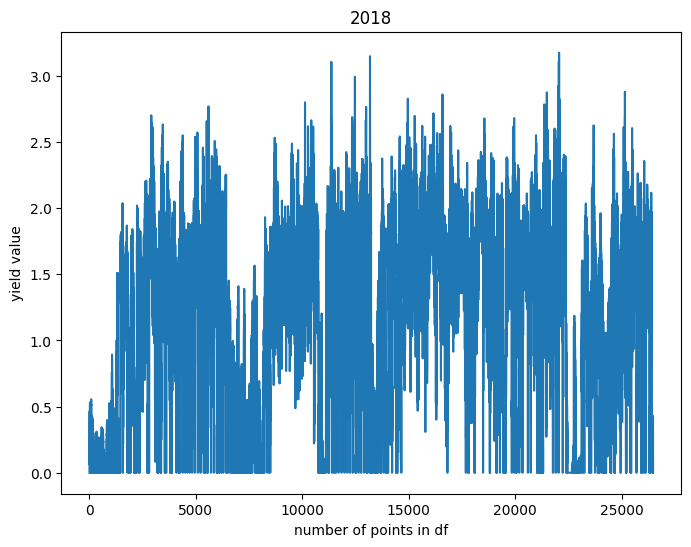

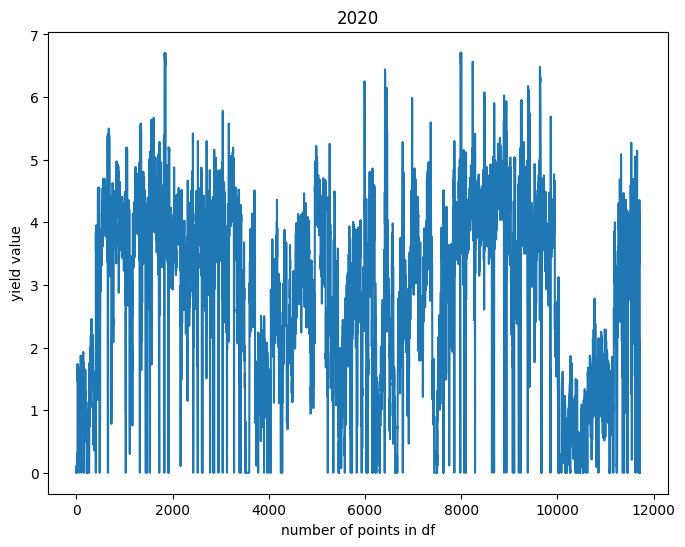

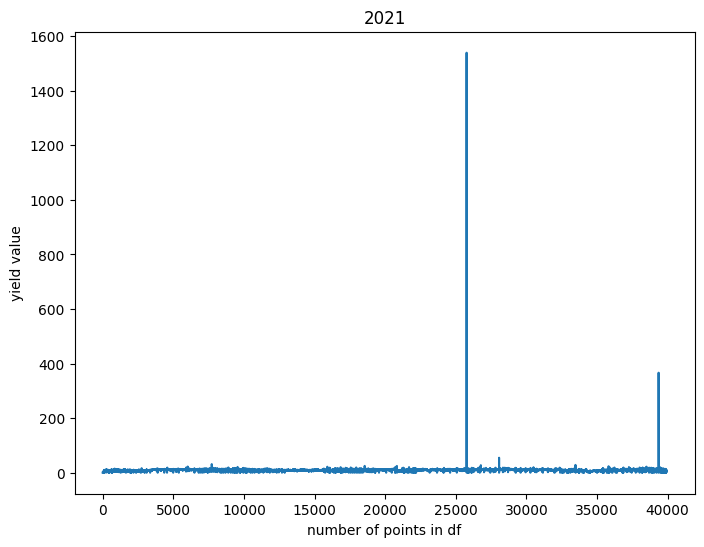

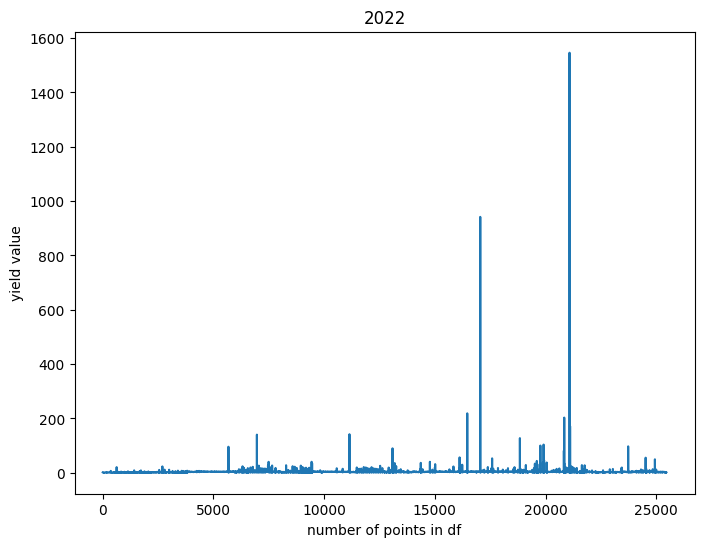

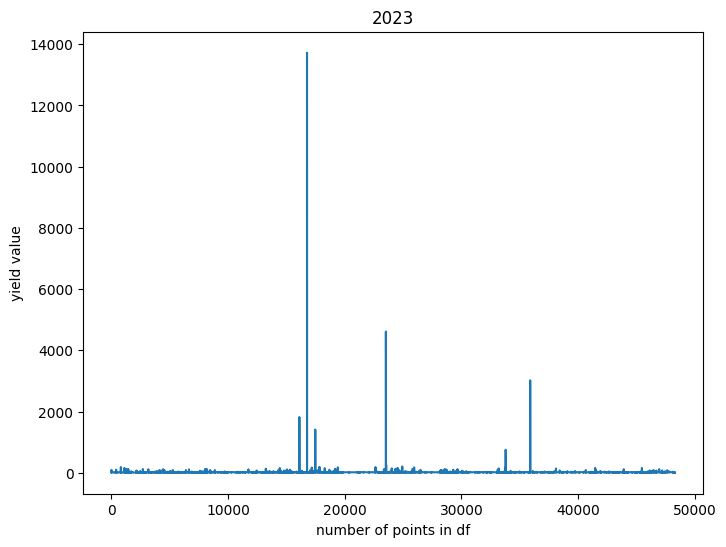

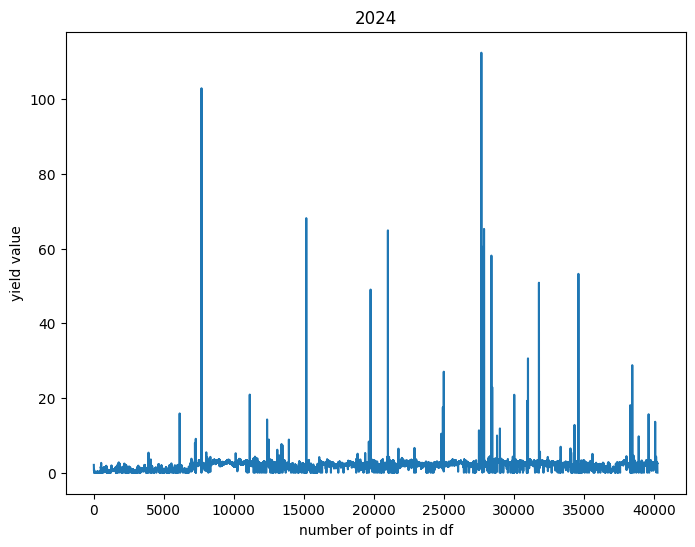

In [ ]:
for i, data_frame in enumerate(all_data_frames_62):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot(kind='line', title=f'Plot of Column {column}')
    plt.title(f"{data_frame['year'][0]}")
    plt.xlabel("number of points in df")
    plt.ylabel("yield value")
    plt.show()

In [ ]:
for i, data_frame in enumerate(all_data_frames_62):
    column = 'VRYIELDMAS'
    print(data_frame['year'][0])
    print(data_frame[column].describe())
    print(" ")
    print(" ")
    print(" ")

2018
count    26472.000000
mean         1.201864
std          0.719480
min          0.000000
25%          0.571064
50%          1.391113
75%          1.795620
max          3.175107
Name: VRYIELDMAS, dtype: float64
 
 
 
2020
count    11715.000000
mean         2.860205
std          1.458780
min          0.000000
25%          1.714927
50%          3.202201
75%          3.981492
max          6.708328
Name: VRYIELDMAS, dtype: float64
 
 
 
2021
count    39907.000000
mean         9.582898
std          8.466820
min          0.000000
25%          8.095449
50%          9.962961
75%         11.414709
max       1539.349227
Name: VRYIELDMAS, dtype: float64
 
 
 
2022
count    25455.000000
mean         2.964375
std         11.889113
min          0.003155
25%          1.962196
50%          2.933153
75%          3.441555
max       1546.409630
Name: VRYIELDMAS, dtype: float64
 
 
 
2023
count    48291.000000
mean        14.526494
std         68.485770
min          0.000000
25%         12.608705
50%  

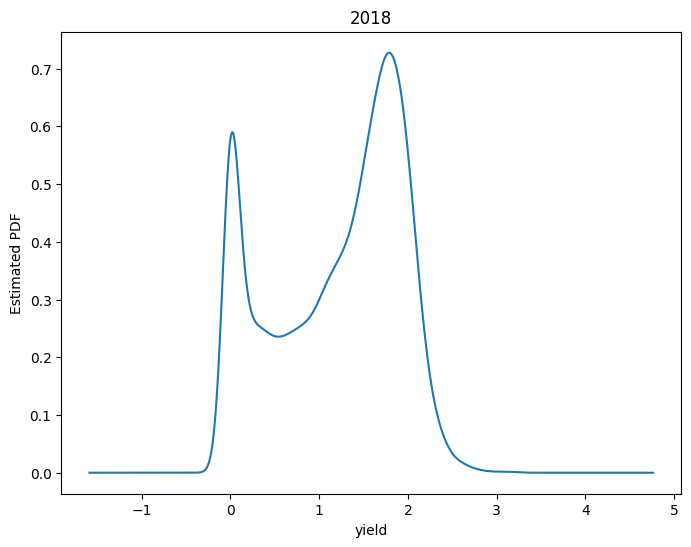

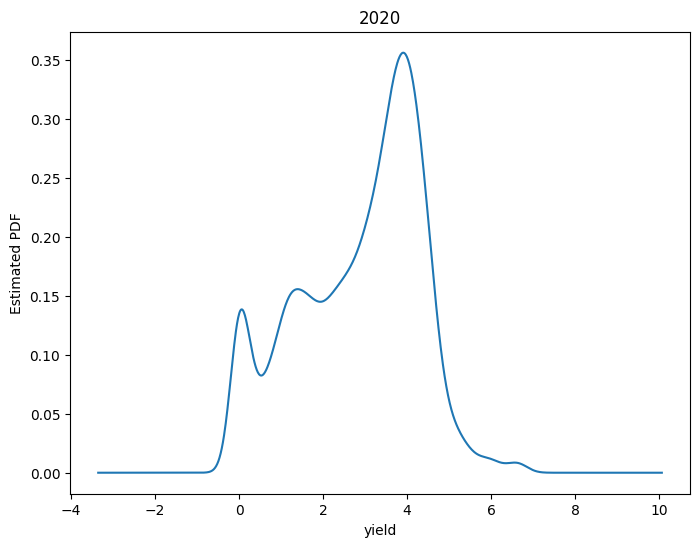

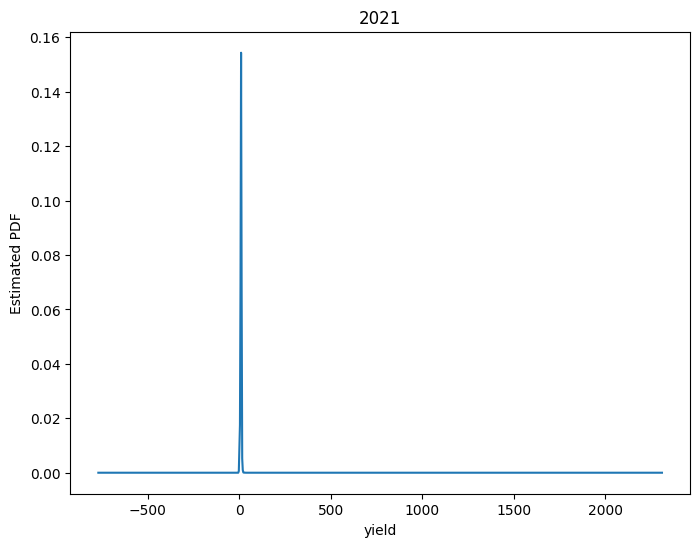

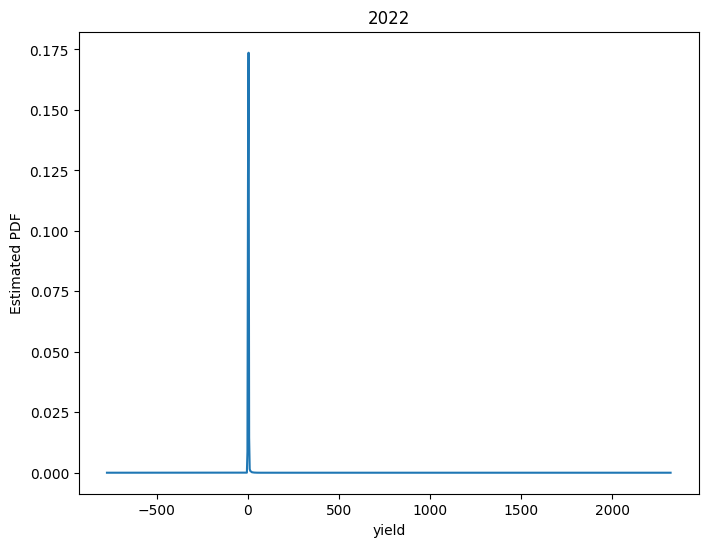

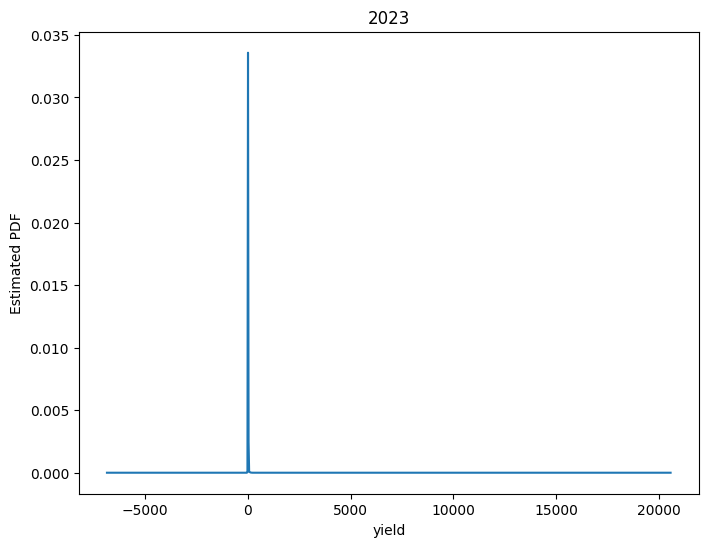

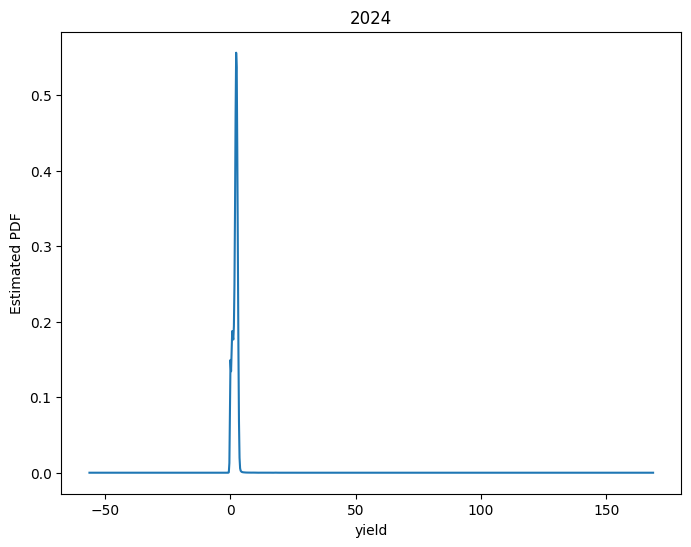

In [ ]:
for i, data_frame in enumerate(all_data_frames_62):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot(kind='kde')
    plt.title(f"{data_frame['year'][0]}")
    plt.xlabel("yield")
    plt.ylabel("Estimated PDF")
    plt.show()

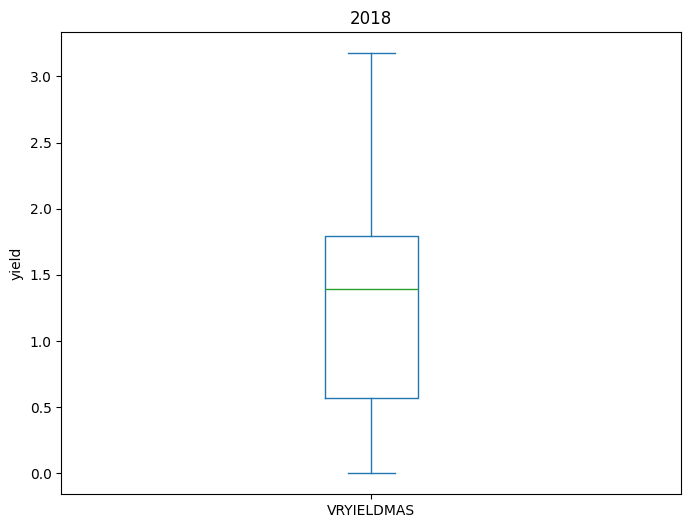

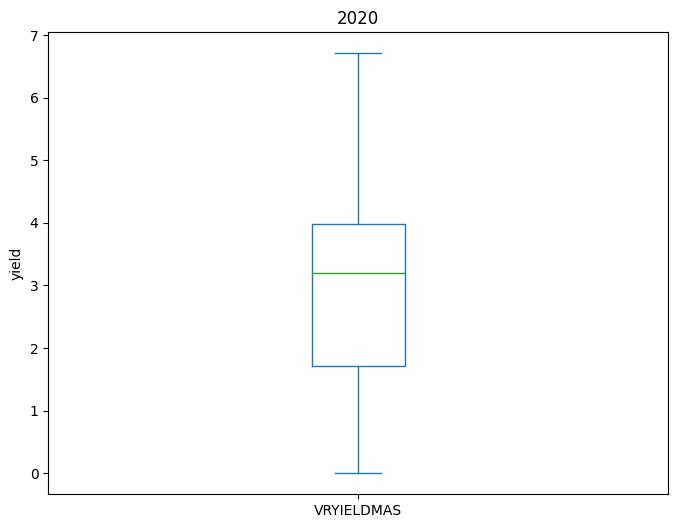

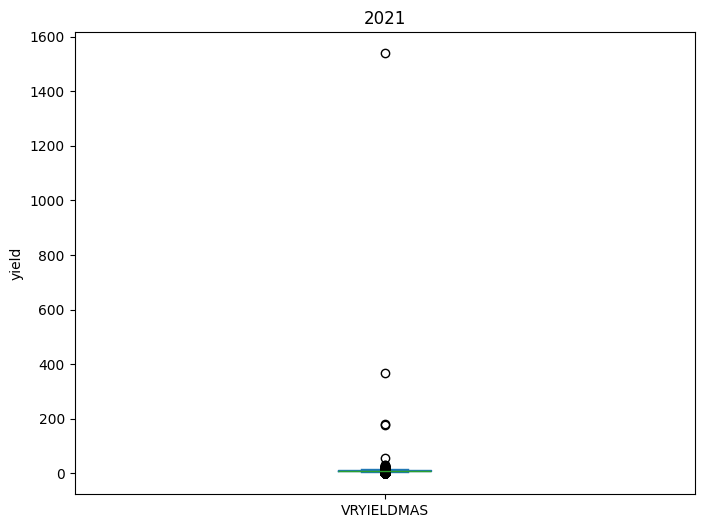

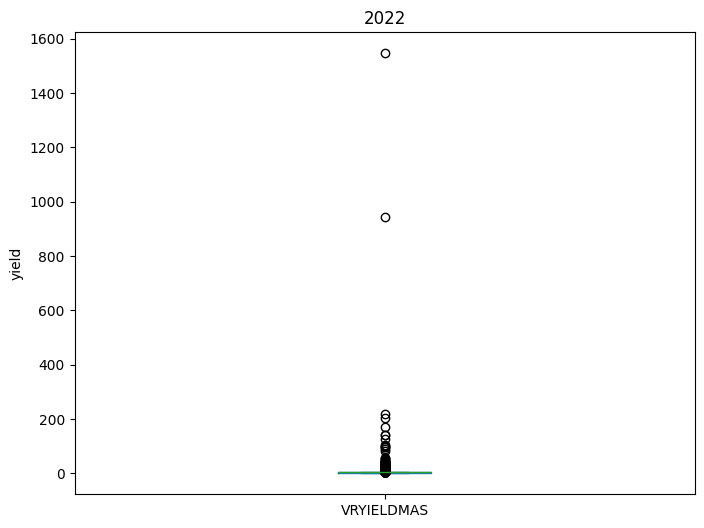

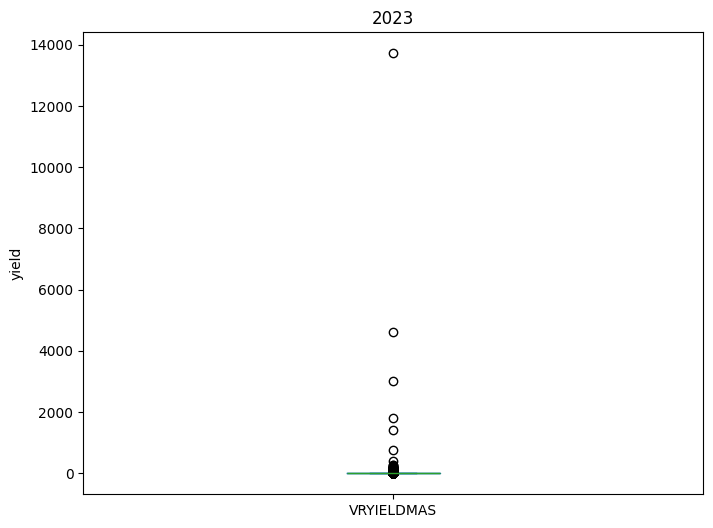

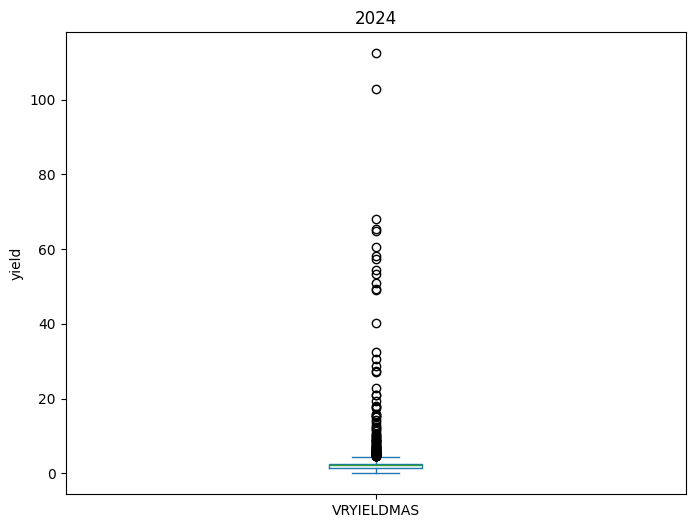

In [ ]:
for i, data_frame in enumerate(all_data_frames_62):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot.box()
    plt.title(f"{data_frame['year'][0]}")
    plt.ylabel("yield")
    plt.show()

Lower bound: -1.2657696875
Upper bound: 3.6324540525


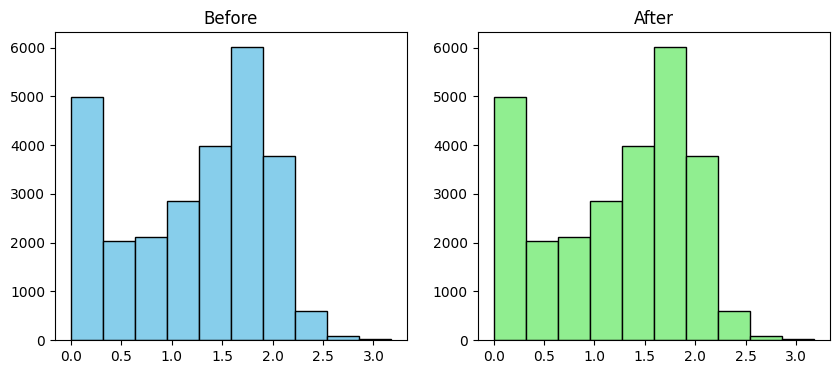

Lower bound: -1.6849189
Upper bound: 7.3813379


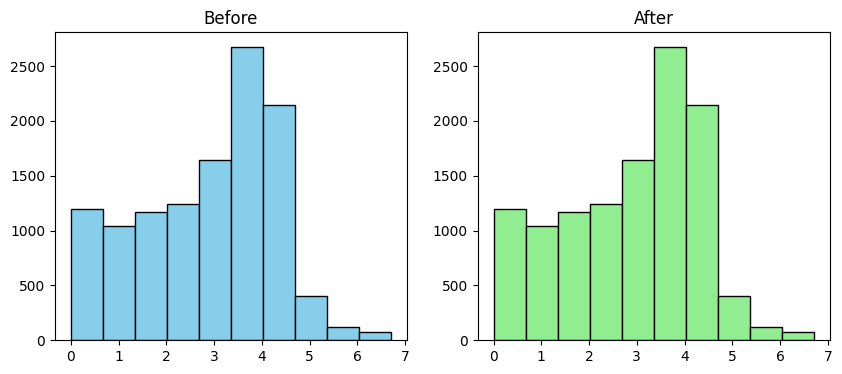

Lower bound: 3.1165600674999965
Upper bound: 16.393597567500002


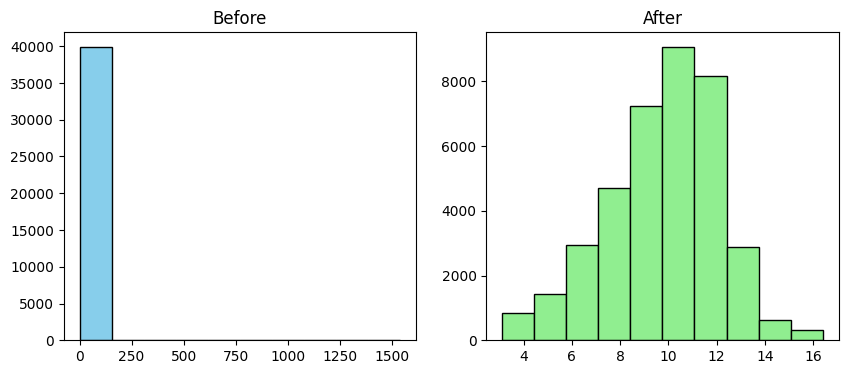

Lower bound: -0.25684158999999984
Upper bound: 5.6605928500000005


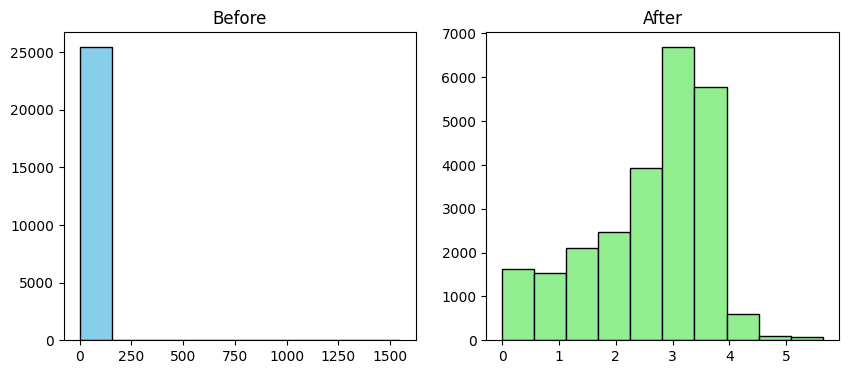

Lower bound: 8.968474085
Upper bound: 18.675757125


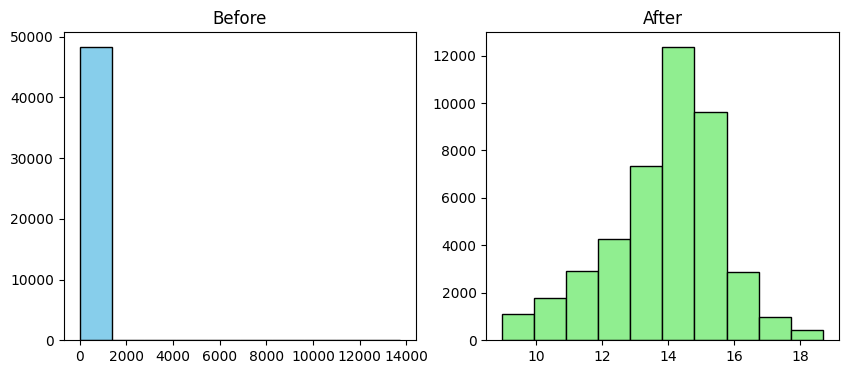

Lower bound: -0.5298486049999998
Upper bound: 4.445247634999999


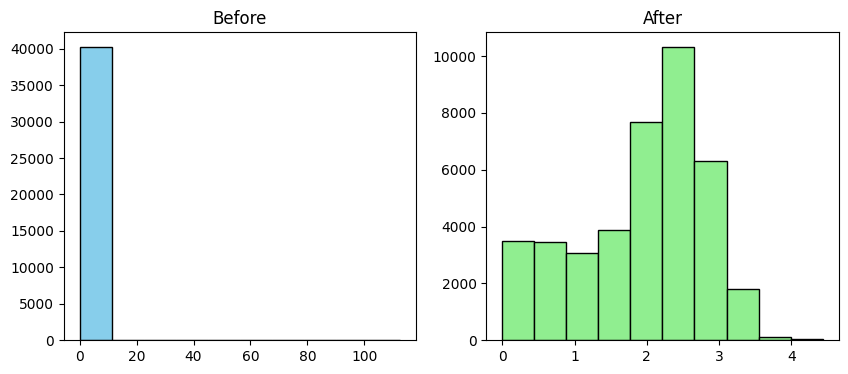

In [ ]:
all_data_frames_new_62 = []
column = 'VRYIELDMAS'

for i, data_frame in enumerate(all_data_frames_62):
    col = data_frame[column].astype(float) 
    Q1 = np.percentile(col, 25)
    Q3 = np.percentile(col, 75)
    IQR = Q3 - Q1
    MEAN = data_frame[column].mean()

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)

    data_frame_ = data_frame[
        (data_frame[column] >= lower_bound) &
        (data_frame[column] <= upper_bound)
    ]

    all_data_frames_new_62.append(data_frame_)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(data_frame[column], bins=10, color="skyblue", edgecolor="black")
    plt.title("Before")
    plt.subplot(1,2,2)
    plt.hist(data_frame_[column], bins=10, color="lightgreen", edgecolor="black")
    plt.title("After")
    plt.show()

In [ ]:
for i in all_data_frames_new_62:
    print(len(i))

26472
11715
38209
24897
43672
40167


In [ ]:
for i, data_frame in enumerate(all_data_frames_new_62):
    column = 'VRYIELDMAS'
    print(data_frame['year'].iloc[0])
    print(data_frame[column].describe())
    print(" ")
    print(" ")
    print(" ")

2018
count    26472.000000
mean         1.201864
std          0.719480
min          0.000000
25%          0.571064
50%          1.391113
75%          1.795620
max          3.175107
Name: VRYIELDMAS, dtype: float64
 
 
 
2020
count    11715.000000
mean         2.860205
std          1.458780
min          0.000000
25%          1.714927
50%          3.202201
75%          3.981492
max          6.708328
Name: VRYIELDMAS, dtype: float64
 
 
 
2021
count    38209.000000
mean         9.774000
std          2.306516
min          3.121749
25%          8.334620
50%         10.044164
75%         11.432910
max         16.385808
Name: VRYIELDMAS, dtype: float64
 
 
 
2022
count    24897.000000
mean         2.600782
std          1.066422
min          0.003155
25%          1.928172
50%          2.905378
75%          3.408583
max          5.641562
Name: VRYIELDMAS, dtype: float64
 
 
 
2023
count    43672.000000
mean        13.920347
std          1.701509
min          8.969360
25%         13.003091
50%  

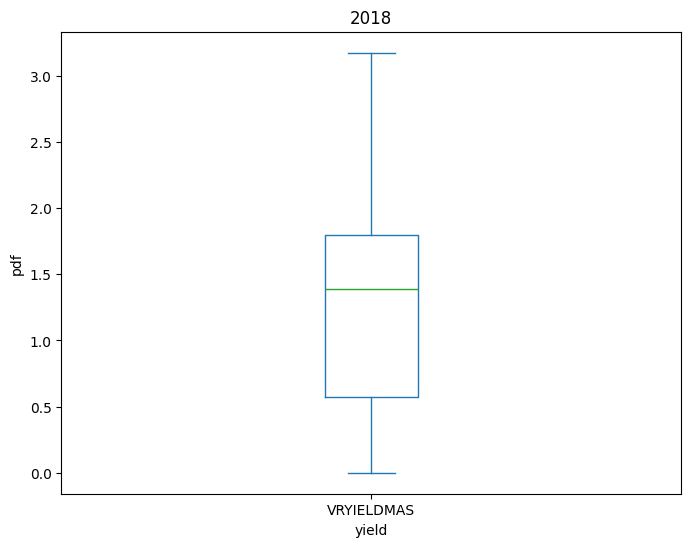

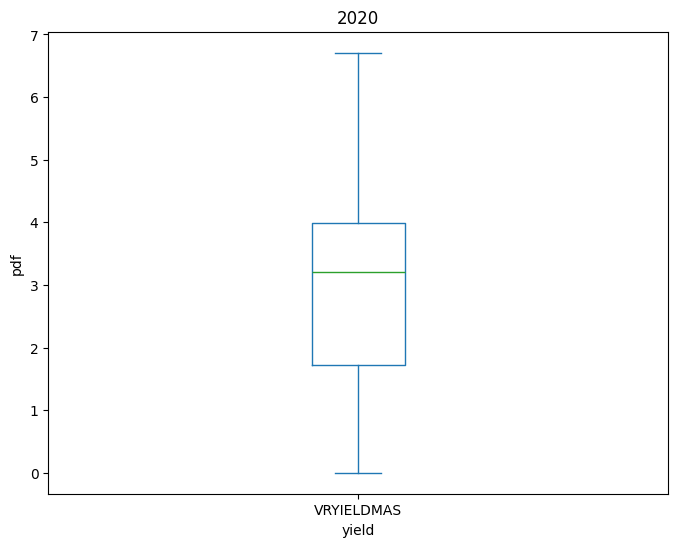

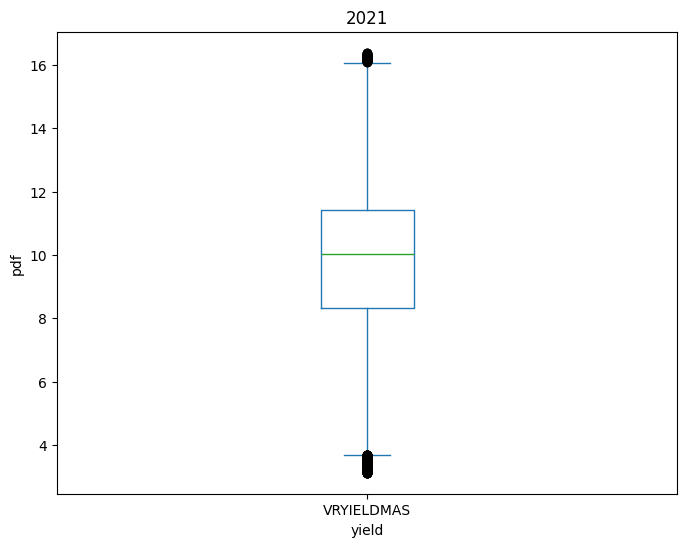

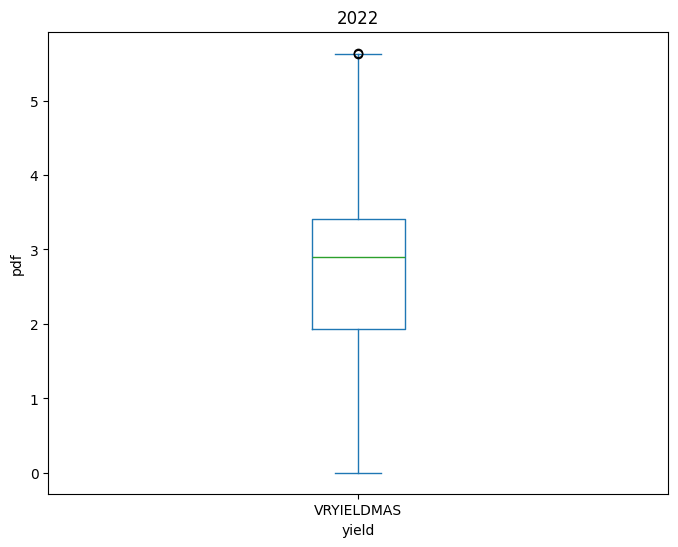

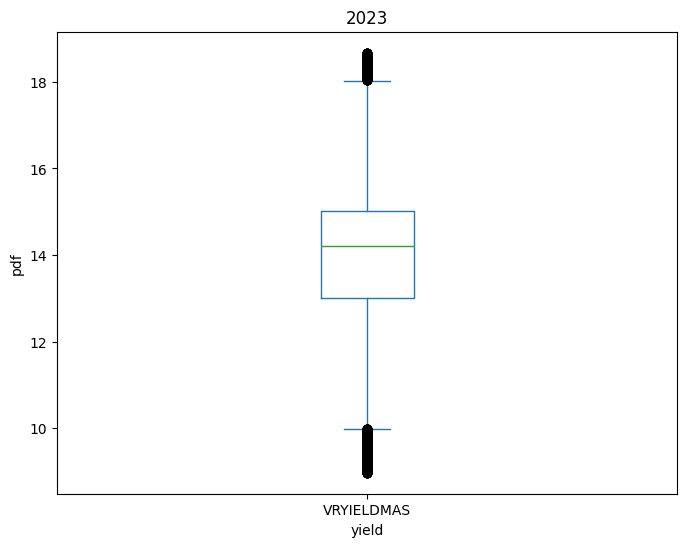

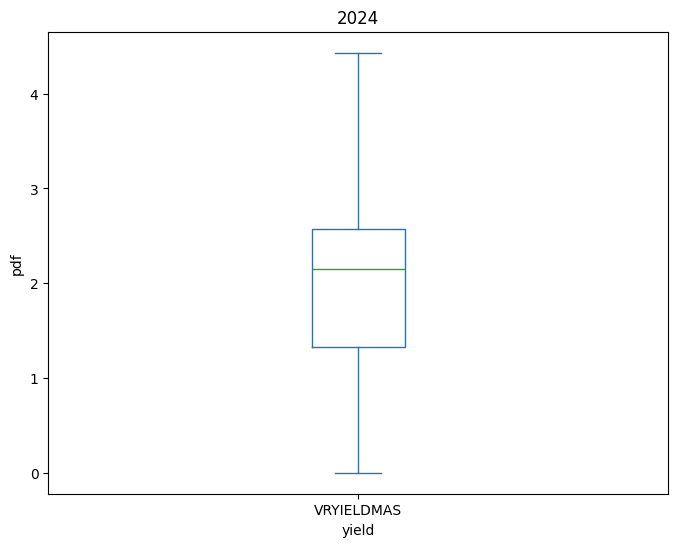

In [ ]:
for i, data_frame in enumerate(all_data_frames_new_62):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot.box()
    plt.title(f"{data_frame['year'][100]}")
    plt.xlabel("yield")
    plt.ylabel("pdf")
    plt.show()

#### field 60

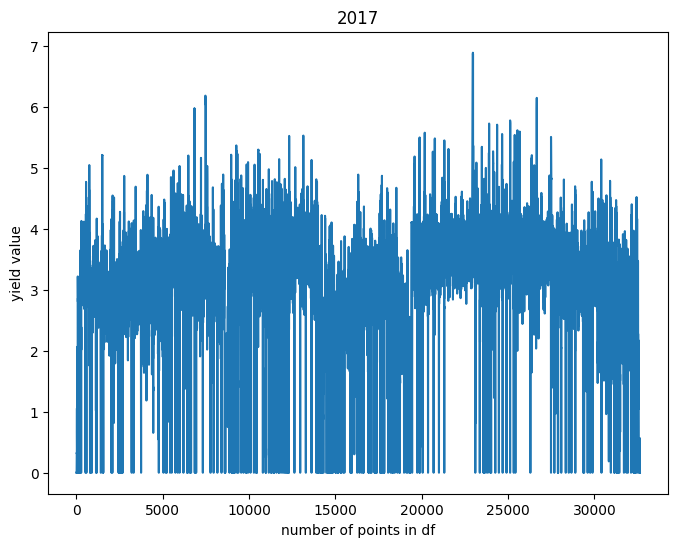

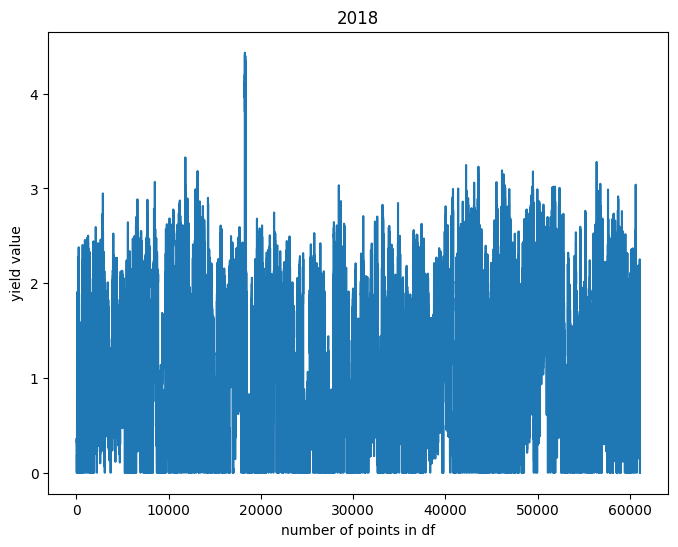

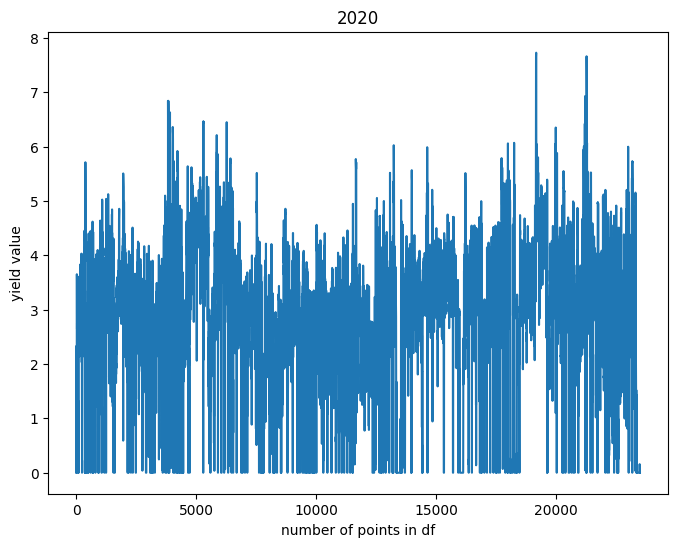

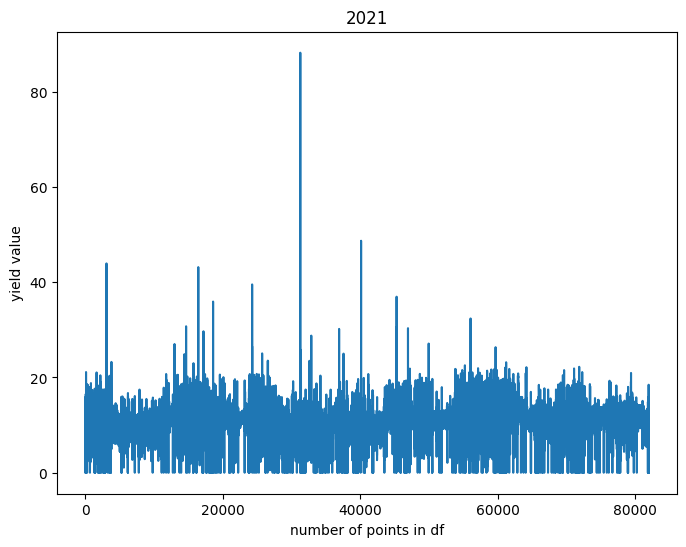

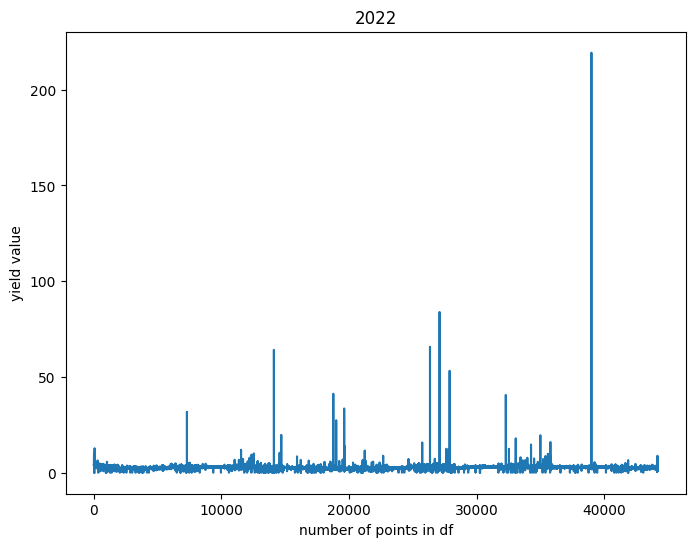

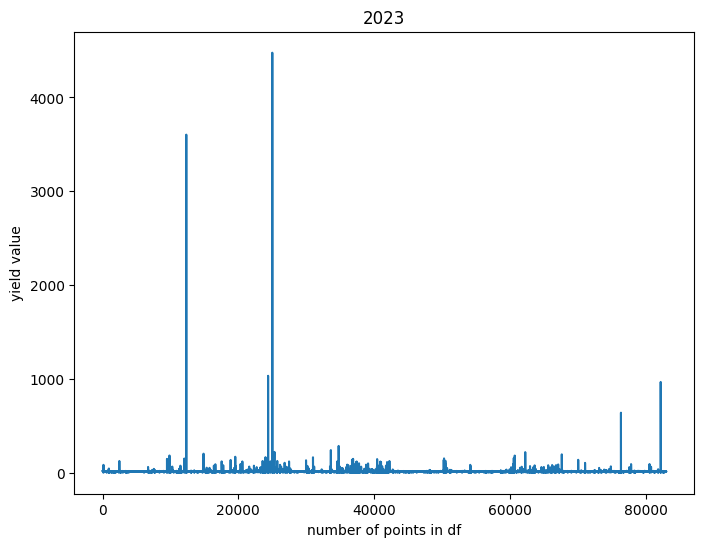

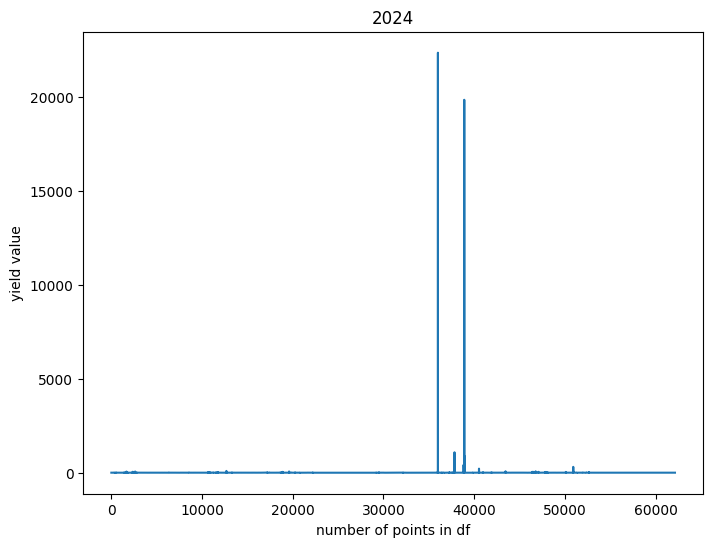

In [ ]:
for i, data_frame in enumerate(all_data_frames_60):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot(kind='line', title=f'Plot of Column {column}')
    plt.title(f"{data_frame['year'][0]}")
    plt.xlabel("number of points in df")
    plt.ylabel("yield value")
    plt.show()

In [ ]:
for i, data_frame in enumerate(all_data_frames_60):
    column = 'VRYIELDMAS'
    print(data_frame['year'][0])
    print(data_frame[column].describe())
    print(" ")
    print(" ")
    print(" ")

2017
count    32635.000000
mean         3.001933
std          1.009418
min          0.000000
25%          2.708505
50%          3.220507
75%          3.599706
max          6.882760
Name: VRYIELDMAS, dtype: float64
 
 
 
2018
count    61085.000000
mean         1.231298
std          0.752814
min          0.000000
25%          0.651394
50%          1.275082
75%          1.835601
max          4.432409
Name: VRYIELDMAS, dtype: float64
 
 
 
2020
count    23503.000000
mean         2.895309
std          1.275896
min          0.000000
25%          2.277668
50%          3.057705
75%          3.684931
max          7.725446
Name: VRYIELDMAS, dtype: float64
 
 
 
2021
count    81942.000000
mean        10.975074
std          2.824390
min          0.000000
25%          9.875451
50%         11.318092
75%         12.447124
max         88.177740
Name: VRYIELDMAS, dtype: float64
 
 
 
2022
count    44163.000000
mean         2.649426
std          1.423388
min          0.000000
25%          2.325905
50%  

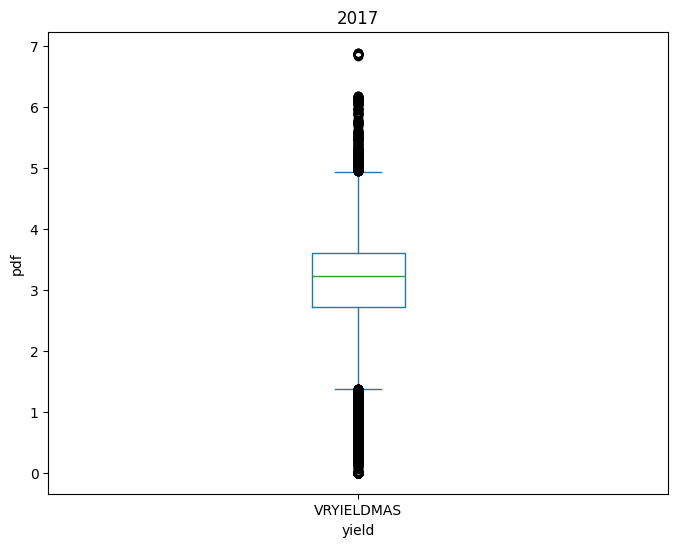

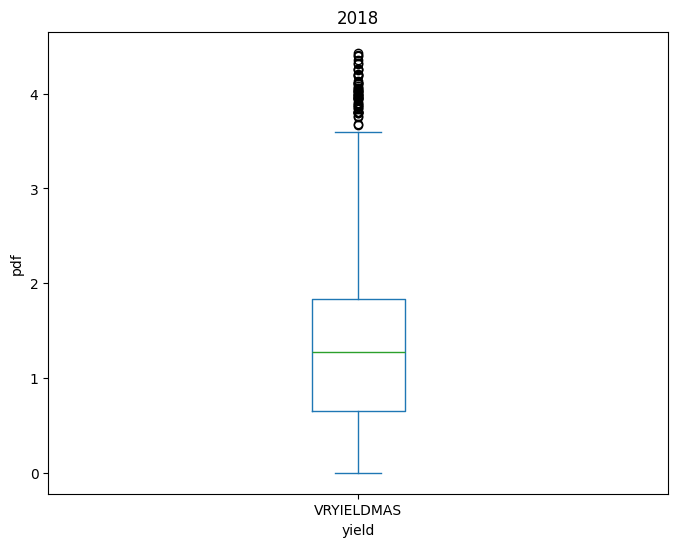

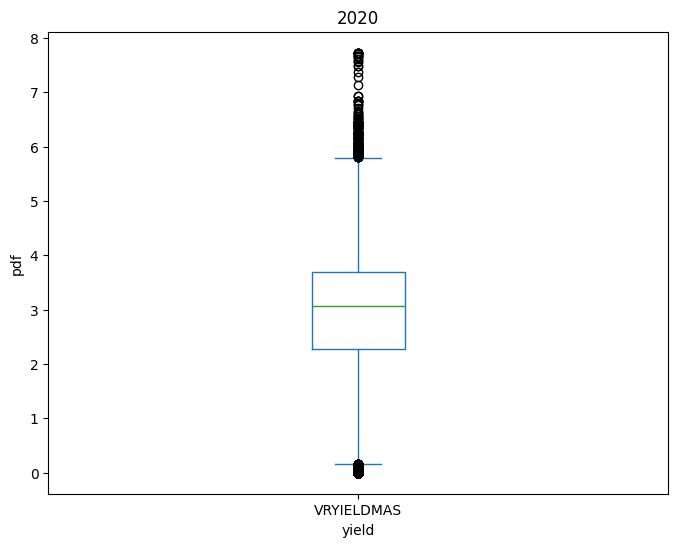

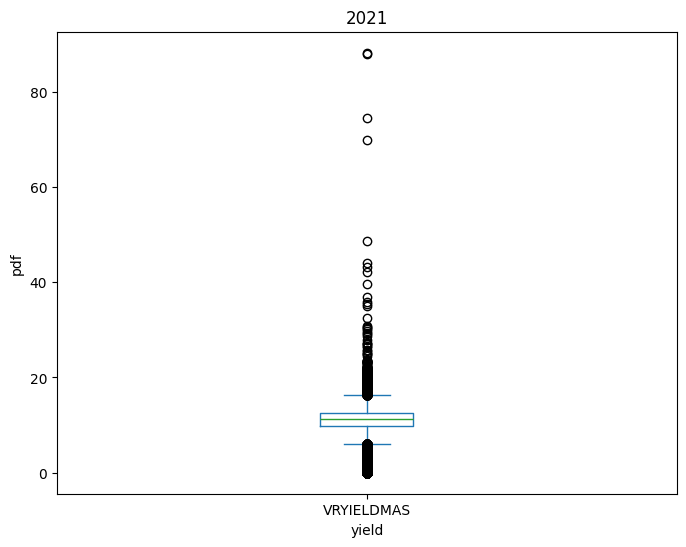

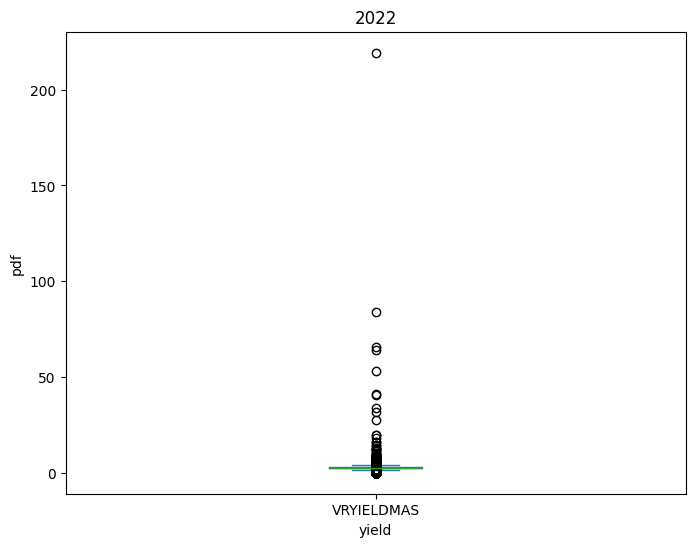

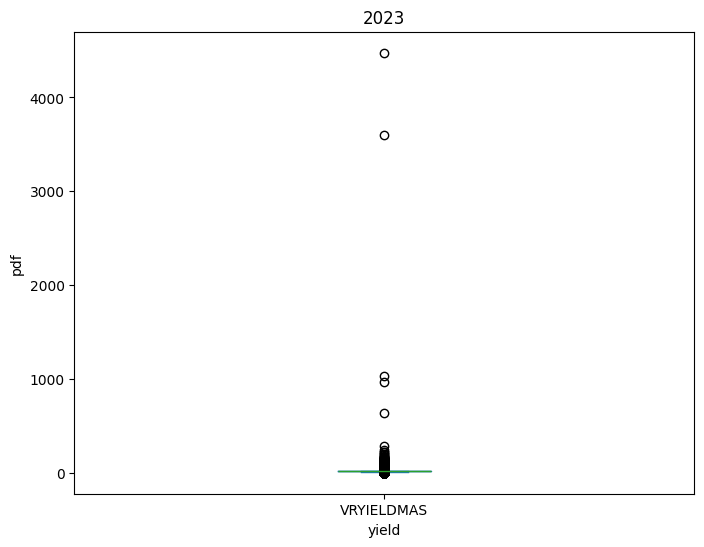

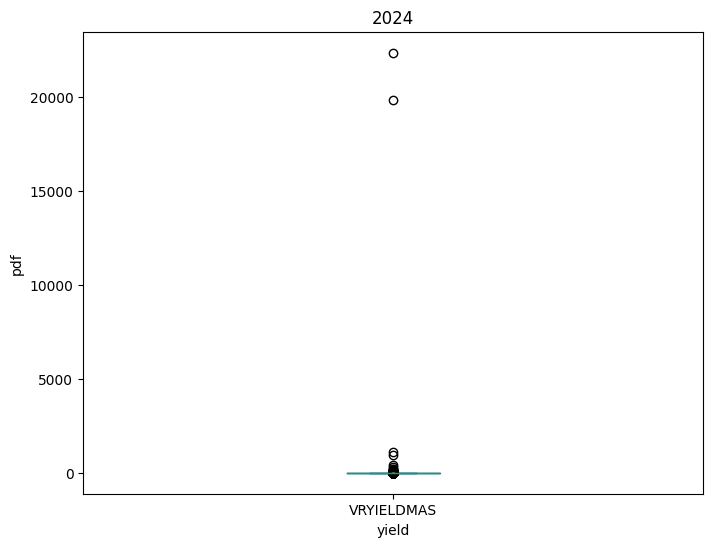

In [ ]:
for i, data_frame in enumerate(all_data_frames_60):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot.box()
    plt.title(f"{data_frame['year'][0]}")
    plt.xlabel("yield")
    plt.ylabel("pdf")
    plt.show()

YEAR:  2017
Lower bound: 1.3717040274999994
Upper bound: 4.936506767500001


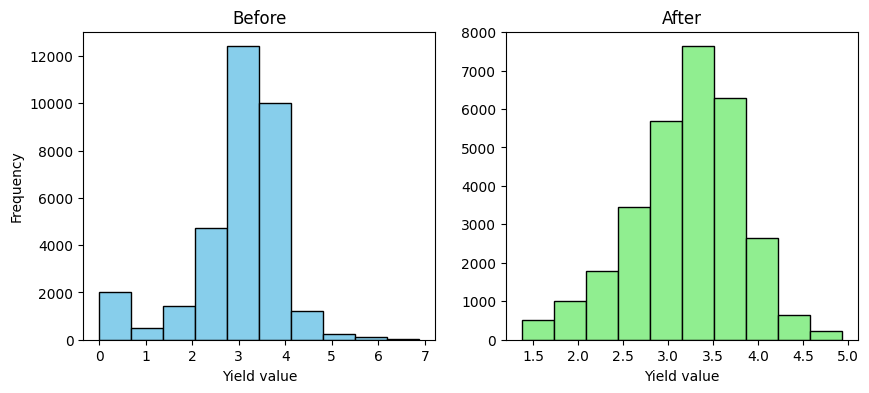

YEAR:  2018
Lower bound: -1.1249156900000004
Upper bound: 3.6119103100000003


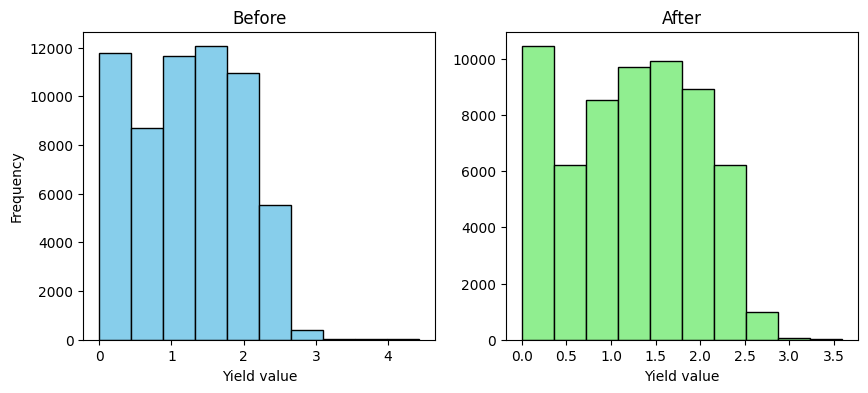

YEAR:  2020
Lower bound: 0.16677177500000084
Upper bound: 5.795827254999999


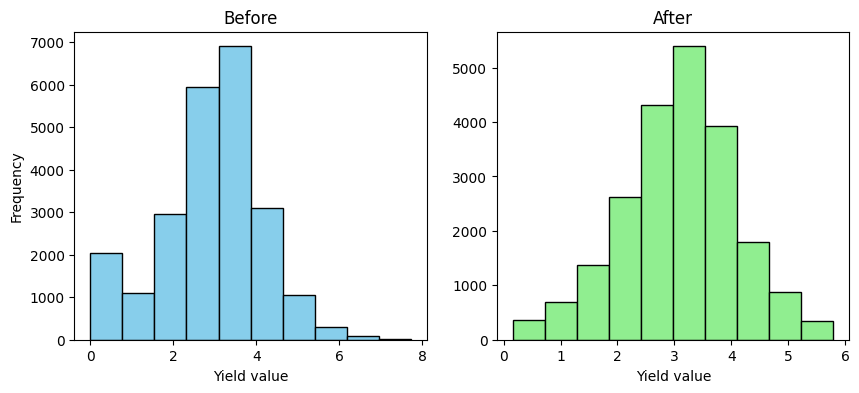

YEAR:  2021
Lower bound: 6.017942832500003
Upper bound: 16.3046321725


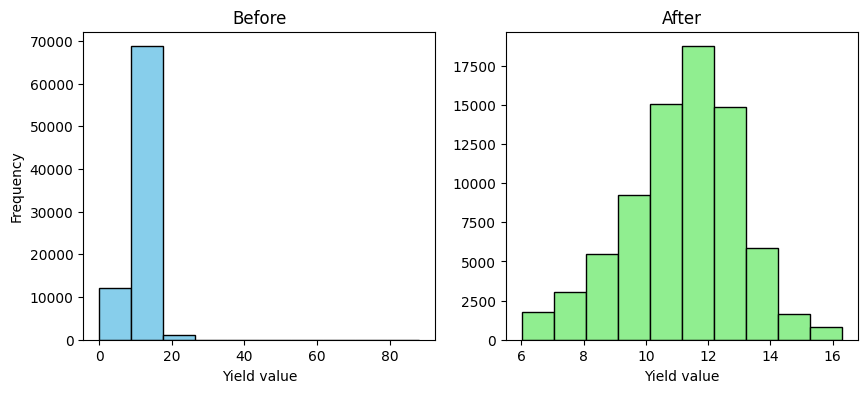

YEAR:  2022
Lower bound: 1.35424412
Upper bound: 3.94534044


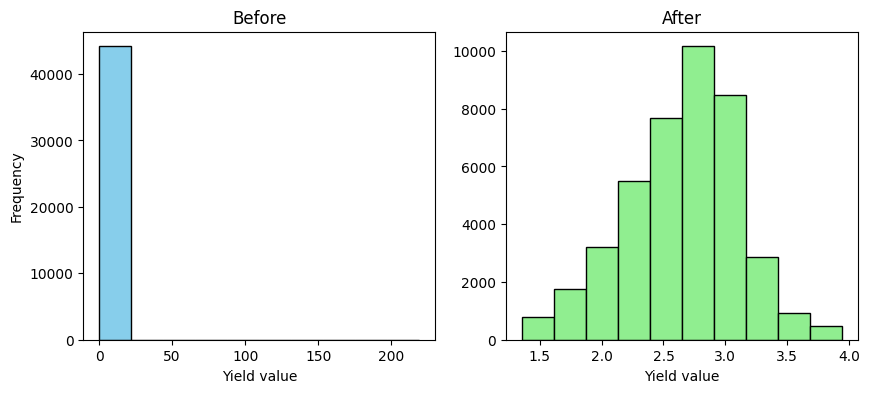

YEAR:  2023
Lower bound: 11.394855262500002
Upper bound: 17.777147642499997


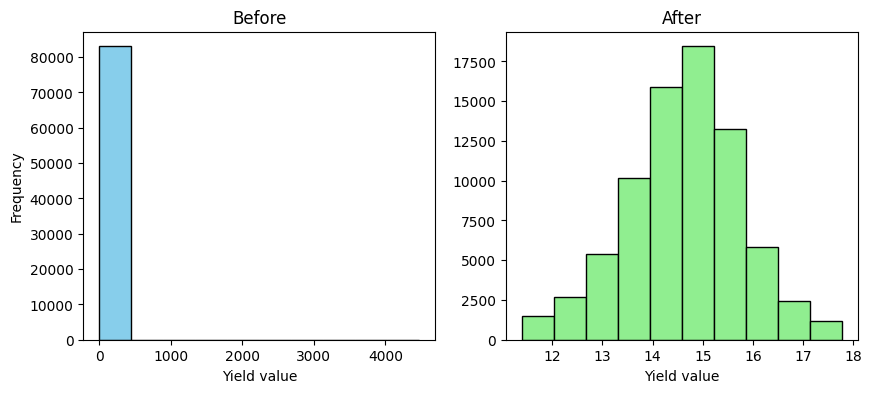

YEAR:  2024
Lower bound: 0.6556371549999997
Upper bound: 3.5444373550000003


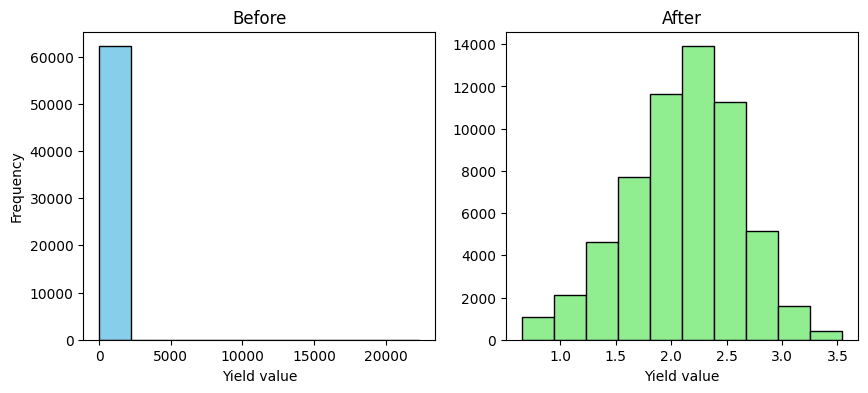

In [ ]:
all_data_frames_new_60 = []
column = 'VRYIELDMAS'

for i, data_frame in enumerate(all_data_frames_60):
    col = data_frame[column].astype(float) 
    Q1 = np.percentile(col, 25)
    Q3 = np.percentile(col, 75)
    IQR = Q3 - Q1
    MEAN = data_frame[column].mean()

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("YEAR: ", f"{data_frame['year'][0]}")
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)

    data_frame_ = data_frame[
        (data_frame[column] >= lower_bound) &
        (data_frame[column] <= upper_bound)
    ]

    all_data_frames_new_60.append(data_frame_)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(data_frame[column], bins=10, color="skyblue", edgecolor="black")
    plt.xlabel("Yield value")
    plt.ylabel("Frequency")
    plt.title("Before")
    plt.subplot(1,2,2)
    plt.hist(data_frame_[column], bins=10, color="lightgreen", edgecolor="black")
    plt.xlabel("Yield value")
    # plt.ylabel("Frequency")
    plt.title("After")
    plt.show()

In [ ]:
all_data_frames_new_60[0]['year']

54       2017
55       2017
56       2017
57       2017
58       2017
         ... 
32553    2017
32554    2017
32559    2017
32561    2017
32563    2017
Name: year, Length: 29849, dtype: int64

In [ ]:
for i, data_frame in enumerate(all_data_frames_new_60):
    column = 'VRYIELDMAS'
    print(data_frame['year'].iloc[0])
    print(data_frame[column].describe())
    print(" ")
    print(" ")
    print(" ")

2017
count    29849.000000
mean         3.208856
std          0.602428
min          1.372153
25%          2.851530
50%          3.274541
75%          3.621421
max          4.933487
Name: VRYIELDMAS, dtype: float64
 
 
 
2018
count    61027.000000
mean         1.228651
std          0.748232
min          0.000000
25%          0.650920
50%          1.273736
75%          1.833532
max          3.593831
Name: VRYIELDMAS, dtype: float64
 
 
 
2020
count    21674.000000
mean         3.085945
std          0.995952
min          0.168016
25%          2.482059
50%          3.134810
75%          3.719554
max          5.790804
Name: VRYIELDMAS, dtype: float64
 
 
 
2021
count    76442.000000
mean        11.187780
std          1.816217
min          6.018515
25%         10.097643
50%         11.370033
75%         12.421635
max         16.300364
Name: VRYIELDMAS, dtype: float64
 
 
 
2022
count    41818.000000
mean         2.653393
std          0.456633
min          1.355052
25%          2.361029
50%  

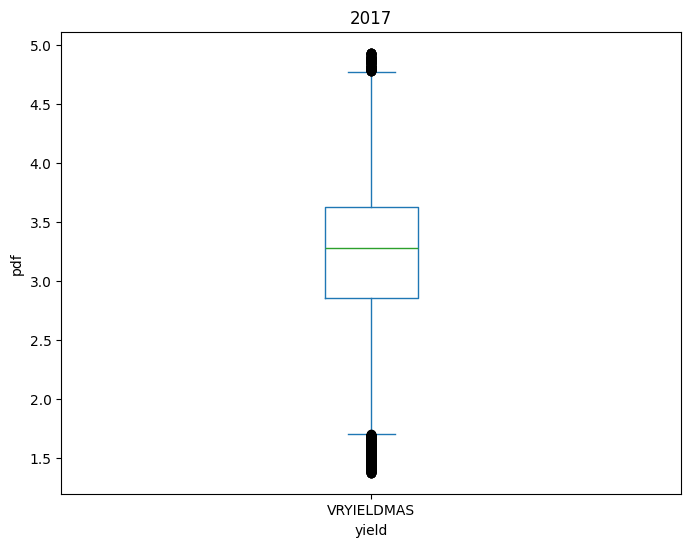

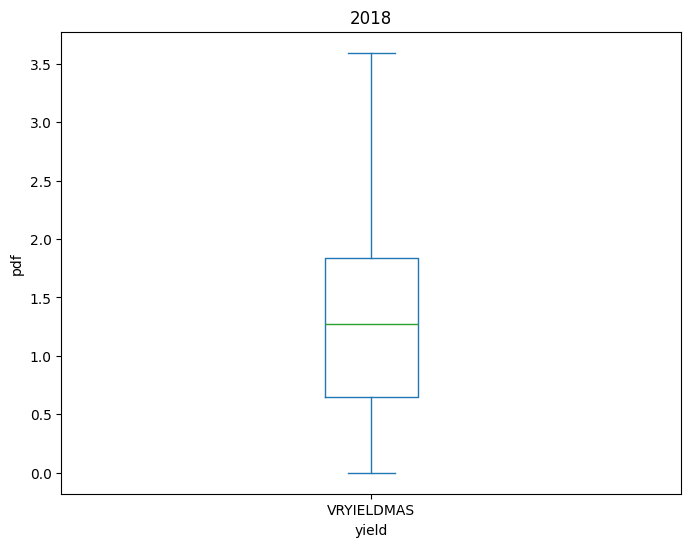

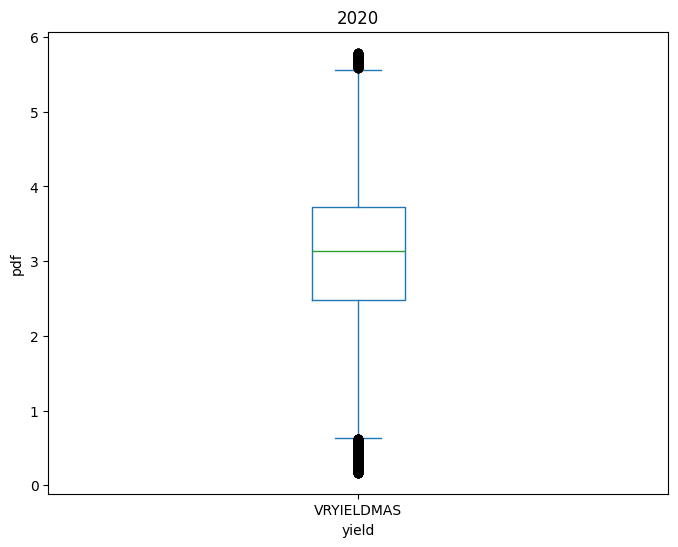

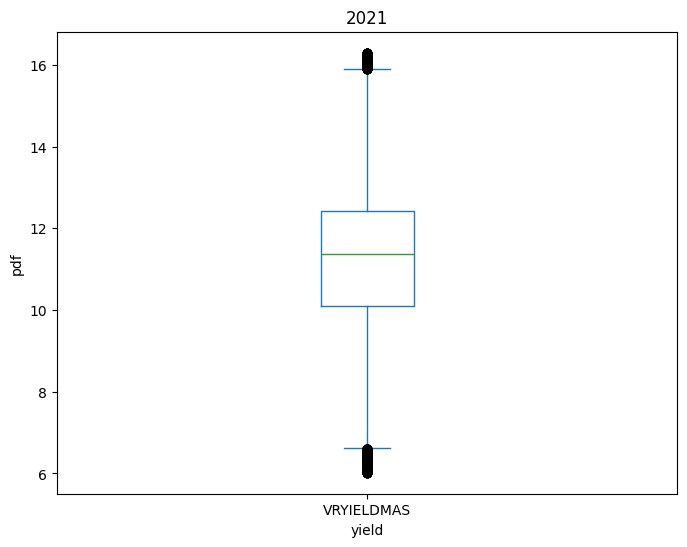

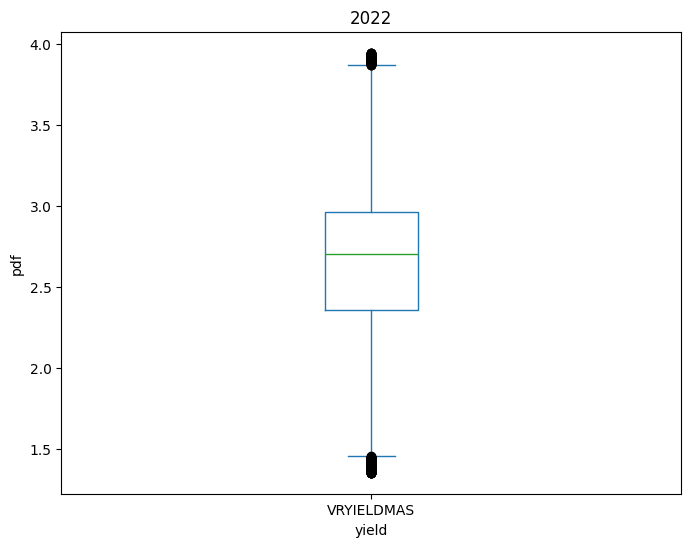

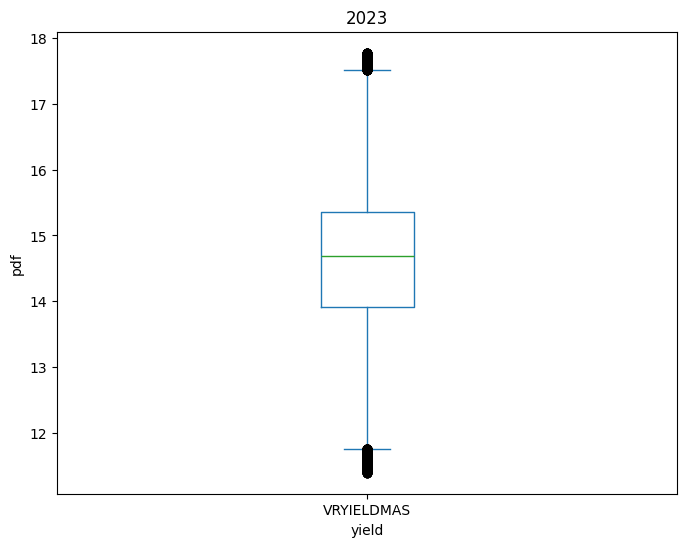

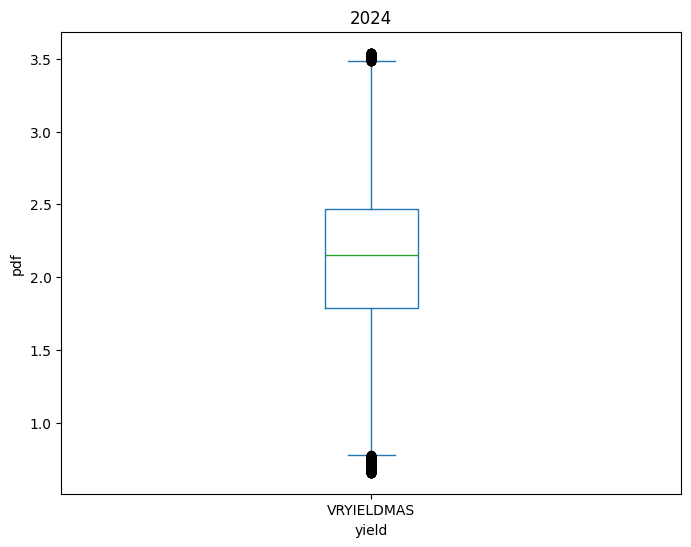

In [ ]:
for i, data_frame in enumerate(all_data_frames_new_60):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot.box()
    plt.title(f"{data_frame['year'].iloc[0]}")
    plt.xlabel("yield")
    plt.ylabel("pdf")
    plt.show()

In [ ]:
cropped_data = pd.concat(all_data_frames_new_62, ignore_index=True)

In [ ]:
len(cropped_data)

185132

In [ ]:
cropped_data_60 = pd.concat(all_data_frames_new_60, ignore_index=True)

In [ ]:
len(cropped_data_60)

367132

In [ ]:
cropped_data.isna().count()

DISTANCE       185132
SWATHWIDTH     185132
VRYIELDMAS     185132
SECTIONID      185132
Crop           185132
WetMass        185132
Moisture       185132
Time           185132
Heading        185132
VARIETY        185132
Elevation      185132
IsoTime        185132
Machine        185132
xcoord         185132
ycoord         185132
area           185132
CROPNAME_      185132
Organic M      185132
Ca             185132
Mg             185132
Mg_Index       185132
Mn             185132
B              185132
Cu             185132
Mo             185132
Fe             185132
Zn             185132
S              185132
P              185132
P_Index        185132
K              185132
K_Index        185132
Na             185132
pH             185132
C.E.C          185132
year           185132
Name           185132
FUEL           185132
VEHICLSPEED    185132
DRYMATTER      185132
PRODUCTHASH    185132
FIELDREF       185132
dtype: int64

In [ ]:
len(cropped_data)

185132

In [ ]:
cropped_data.columns

Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year', 'Name', 'FUEL',
       'VEHICLSPEED', 'DRYMATTER', 'PRODUCTHASH', 'FIELDREF'],
      dtype='object')

In [ ]:
clear_cropped_data = cropped_data.drop(columns=['FIELDREF', 'DISTANCE', 'SWATHWIDTH',
                                                 'WetMass', 'Time', 'Heading',
                                                'VARIETY', 'IsoTime', 'Machine', 
                                                'FUEL', 'VEHICLSPEED', 'PRODUCTHASH',
                                                'Name', 'DRYMATTER', 'P_Index', 
                                                'K_Index', 'Mg_Index', "CROPNAME_"])
clear_cropped_data.head()

,VRYIELDMAS,SECTIONID,Crop,Moisture,Elevation,xcoord,ycoord,area,Organic M,Ca,...,Mo,Fe,Zn,S,P,K,Na,pH,C.E.C,year
0,0.000000,499,45,14.38,269.856182,25.839963,48.834206,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018
1,0.186290,499,45,14.41,269.818182,25.839974,48.834226,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018
2,0.000000,499,45,14.44,269.751182,25.839979,48.834244,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018
3,0.143233,499,45,14.45,269.748182,25.839986,48.834261,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018
4,0.000000,499,45,14.24,269.713182,25.839996,48.834278,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018


In [ ]:
clear_cropped_data_60 = cropped_data_60.drop(columns=['FIELDREF', 'DISTANCE', 'SWATHWIDTH',
                                                 'WetMass', 'Time', 'Heading',
                                                'VARIETY', 'IsoTime', 'Machine', 
                                                'FUEL', 'VEHICLSPEED', 'PRODUCTHASH',
                                                'Name', 'DRYMATTER', 'P_Index', 
                                                'K_Index', 'Mg_Index', "CROPNAME_",
                                                'SKYCNDTN', 'HUMIDITY', 'Unnamed: 0'])
clear_cropped_data_60.head()

,VRYIELDMAS,SECTIONID,Crop,Moisture,Elevation,area,Organic M.,Ca,Mg,Mn,...,Mo,Fe,Zn,S,P,K,Na,pH,C.E.C,year
0,1.384943,1716,33,13.07,296.027082,4.7,4.7,4001.0,158.0,193.0,...,0.04,129.0,1.7,15.0,8.0,204.0,11.0,8.1,22.5,2017
1,1.492232,1716,33,13.13,296.047082,4.7,4.7,4001.0,158.0,193.0,...,0.04,129.0,1.7,15.0,8.0,204.0,11.0,8.1,22.5,2017
2,1.655677,1716,33,13.14,296.041082,4.7,4.7,4001.0,158.0,193.0,...,0.04,129.0,1.7,15.0,8.0,204.0,11.0,8.1,22.5,2017
3,1.825828,1716,33,13.15,296.050082,4.7,4.7,4001.0,158.0,193.0,...,0.04,129.0,1.7,15.0,8.0,204.0,11.0,8.1,22.5,2017
4,1.825828,1716,33,13.17,296.044082,4.7,4.7,4001.0,158.0,193.0,...,0.04,129.0,1.7,15.0,8.0,204.0,11.0,8.1,22.5,2017


In [ ]:
clear_cropped_data = pd.get_dummies(clear_cropped_data, columns=['Crop'], drop_first=False)

In [ ]:
clear_cropped_data_60 = pd.get_dummies(clear_cropped_data_60, columns=['Crop'], drop_first=False)

In [ ]:
clear_cropped_data.columns

Index(['VRYIELDMAS', 'SECTIONID', 'Moisture', 'Elevation', 'xcoord', 'ycoord',
       'area', 'Organic M', 'Ca', 'Mg', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S',
       'P', 'K', 'Na', 'pH', 'C.E.C', 'year', 'Crop_22', 'Crop_34', 'Crop_41',
       'Crop_45', 'Crop_174'],
      dtype='object')

In [ ]:
clear_cropped_data_60.columns

Index(['VRYIELDMAS', 'SECTIONID', 'Moisture', 'Elevation', 'area',
       'Organic M.', 'Ca', 'Mg', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'K', 'Na', 'pH', 'C.E.C', 'year', 'Crop_33', 'Crop_34', 'Crop_41',
       'Crop_45', 'Crop_174'],
      dtype='object')

In [ ]:
clear_cropped_data.isna().sum()

VRYIELDMAS    0
SECTIONID     0
Moisture      0
Elevation     0
xcoord        0
ycoord        0
area          0
Organic M     0
Ca            0
Mg            0
Mn            0
B             0
Cu            0
Mo            0
Fe            0
Zn            0
S             0
P             0
K             0
Na            0
pH            0
C.E.C         0
year          0
Crop_22       0
Crop_34       0
Crop_41       0
Crop_45       0
Crop_174      0
dtype: int64

In [ ]:
clear_cropped_data_60.isna().sum()

VRYIELDMAS     0
SECTIONID      0
Moisture       0
Elevation      0
area          25
Organic M.    25
Ca            25
Mg            25
Mn            25
B             25
Cu            25
Mo            25
Fe            25
Zn            25
S             25
P             25
K             25
Na            25
pH            25
C.E.C         25
year           0
Crop_33        0
Crop_34        0
Crop_41        0
Crop_45        0
Crop_174       0
dtype: int64

In [ ]:
# clear_cropped_data.tail()

In [ ]:
clear_cropped_data.fillna(clear_cropped_data.mean(), inplace=True)

In [ ]:
clear_cropped_data_60.fillna(clear_cropped_data_60.mean(), inplace=True)

In [ ]:
len(clear_cropped_data)

185132

In [ ]:
len(clear_cropped_data_60)

367132

In [ ]:
clear_cropped_data.to_csv('./data_1/all_yields.csv', index=False)

In [ ]:
clear_cropped_data_60.to_csv('./data_1/all_yields_60.csv', index=False)

In [ ]:
clear_cropped_data_60

,VRYIELDMAS,SECTIONID,Moisture,Elevation,area,Organic M.,Ca,Mg,Mn,B,...,K,Na,pH,C.E.C,year,Crop_33,Crop_34,Crop_41,Crop_45,Crop_174
0,1.384943,1716,13.07,296.027082,4.70,4.7,4001.0,158.0,193.0,3.31,...,204.0,11.0,8.1,22.5,2017,True,False,False,False,False
1,1.492232,1716,13.13,296.047082,4.70,4.7,4001.0,158.0,193.0,3.31,...,204.0,11.0,8.1,22.5,2017,True,False,False,False,False
2,1.655677,1716,13.14,296.041082,4.70,4.7,4001.0,158.0,193.0,3.31,...,204.0,11.0,8.1,22.5,2017,True,False,False,False,False
3,1.825828,1716,13.15,296.050082,4.70,4.7,4001.0,158.0,193.0,3.31,...,204.0,11.0,8.1,22.5,2017,True,False,False,False,False
4,1.825828,1716,13.17,296.044082,4.70,4.7,4001.0,158.0,193.0,3.31,...,204.0,11.0,8.1,22.5,2017,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367127,2.926798,2195,12.00,284.937000,4.22,5.4,4930.0,119.0,195.0,4.42,...,175.0,6.0,8.3,26.6,2024,False,False,False,False,True
367128,2.686837,2195,12.00,284.884000,4.22,5.4,4930.0,119.0,195.0,4.42,...,175.0,6.0,8.3,26.6,2024,False,False,False,False,True
367129,2.490991,2195,12.00,284.802000,4.22,5.4,4930.0,119.0,195.0,4.42,...,175.0,6.0,8.3,26.6,2024,False,False,False,False,True
367130,2.242187,2195,12.00,284.668000,4.22,5.4,4930.0,119.0,195.0,4.42,...,175.0,6.0,8.3,26.6,2024,False,False,False,False,True


In [ ]:
final_df = clear_cropped_data.merge(
    wether_table,
    on='year',
    how='left'
)

In [ ]:
len(final_df)

185132

In [ ]:
final_df

,VRYIELDMAS,SECTIONID,Moisture,Elevation,xcoord,ycoord,area,Organic M,Ca,Mg,...,mean_cloudcover_month_7,mean_cloudcover_month_8,mean_cloudcover_month_9,mean_cloudcover_month_10,std_cloudcover_month_5,std_cloudcover_month_6,std_cloudcover_month_7,std_cloudcover_month_8,std_cloudcover_month_9,std_cloudcover_month_10
0,0.000000,499,14.38,269.856182,25.839963,48.834206,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
1,0.186290,499,14.41,269.818182,25.839974,48.834226,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
2,0.000000,499,14.44,269.751182,25.839979,48.834244,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
3,0.143233,499,14.45,269.748182,25.839986,48.834261,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
4,0.000000,499,14.24,269.713182,25.839996,48.834278,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185127,0.281828,2373,12.00,289.456031,25.838831,48.828348,4.71,6.0,4779.0,168.0,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.08093
185128,0.153946,2373,12.00,289.436031,25.838806,48.828337,4.71,6.0,4779.0,168.0,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.08093
185129,0.135194,2373,12.00,289.436031,25.838781,48.828327,4.71,6.0,4779.0,168.0,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.08093
185130,0.113808,2373,12.00,289.463031,25.838757,48.828315,4.71,6.0,4779.0,168.0,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.08093


In [ ]:
final_df_60 = clear_cropped_data_60.merge(
    wether_table,
    on='year',
    how='left'
)

In [ ]:
final_df_60

,VRYIELDMAS,SECTIONID,Moisture,Elevation,area,Organic M.,Ca,Mg,Mn,B,...,mean_cloudcover_month_7,mean_cloudcover_month_8,mean_cloudcover_month_9,mean_cloudcover_month_10,std_cloudcover_month_5,std_cloudcover_month_6,std_cloudcover_month_7,std_cloudcover_month_8,std_cloudcover_month_9,std_cloudcover_month_10
0,1.384943,1716,13.07,296.027082,4.70,4.7,4001.0,158.0,193.0,3.31,...,60.364516,46.370968,62.620000,73.532258,20.703984,20.713809,21.023757,29.033489,28.635274,26.921446
1,1.492232,1716,13.13,296.047082,4.70,4.7,4001.0,158.0,193.0,3.31,...,60.364516,46.370968,62.620000,73.532258,20.703984,20.713809,21.023757,29.033489,28.635274,26.921446
2,1.655677,1716,13.14,296.041082,4.70,4.7,4001.0,158.0,193.0,3.31,...,60.364516,46.370968,62.620000,73.532258,20.703984,20.713809,21.023757,29.033489,28.635274,26.921446
3,1.825828,1716,13.15,296.050082,4.70,4.7,4001.0,158.0,193.0,3.31,...,60.364516,46.370968,62.620000,73.532258,20.703984,20.713809,21.023757,29.033489,28.635274,26.921446
4,1.825828,1716,13.17,296.044082,4.70,4.7,4001.0,158.0,193.0,3.31,...,60.364516,46.370968,62.620000,73.532258,20.703984,20.713809,21.023757,29.033489,28.635274,26.921446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367127,2.926798,2195,12.00,284.937000,4.22,5.4,4930.0,119.0,195.0,4.42,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.080930
367128,2.686837,2195,12.00,284.884000,4.22,5.4,4930.0,119.0,195.0,4.42,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.080930
367129,2.490991,2195,12.00,284.802000,4.22,5.4,4930.0,119.0,195.0,4.42,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.080930
367130,2.242187,2195,12.00,284.668000,4.22,5.4,4930.0,119.0,195.0,4.42,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.080930


In [ ]:
final_df.to_csv('./data_1/all_yields_.csv', index=False)

In [ ]:
final_df_60.to_csv('./data_1/all_yields_60_.csv', index=False)